In [1]:
# %matplotlib ipympl

In [1]:
import contextlib
import itertools
import multiprocessing as mp
import random
from pathlib import Path

import neurokit2 as nk
import numpy as np
import pandas as pd
import pyPPG
import pyPPG.example
import scipy.io
import scipy.signal
from matplotlib import pyplot as plt
from tqdm import notebook, tqdm

In [2]:
data_dir = Path('data')

In [3]:
images_dir = Path('images')

In [4]:
csv_dir = data_dir / 'csvs'

In [5]:
ppg_dir = data_dir / 'ppg'

In [6]:
pyppg_dir = data_dir / 'pyppg'

In [7]:
subjects_path = csv_dir / 'subjects.csv'

In [8]:
df_subjects = pd.read_csv(subjects_path)

In [9]:
df_subjects['patient_file'] = df_subjects.apply(lambda r: ppg_dir / f'p{r["subject_id"]:06d}_{r["segment_id"]}.mat', axis=1)

In [10]:
fs = 125

In [11]:
def make_filter(design: str, wn: int):
    if design == 'cheby2':
        filt = scipy.signal.cheby2(4, 20, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'butter':
        filt = scipy.signal.butter(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    elif design == 'bessel':
        filt = scipy.signal.bessel(4, wn, btype='band' if isinstance(wn, list) else 'low', fs=fs, output='sos')
    else:
        raise NotImplementedError
    return filt

In [12]:
target_num_cycles = 30

In [13]:
# discard first and last cycles from each signal
# check how many viable cycles each signal has
# settle on a number of cycles for all signals (maybe the minimum number of viable cycles)
# either: randomly sample cycles from signals with many cycles available
# or: sort cycles by quality and choose cycles with most quality
# get average cycle and try to detect points

In [13]:
import pyPPG.fiducials as FP
from pyPPG import PPG, Fiducials
from pyPPG.datahandling import load_data

In [14]:
def ppg_example(data_path="", start_sig=0, end_sig=-1, channel="Pleth", peaks=None, onsets=None,
                smoothing=False, sm_wins={'ppg': 50, 'vpg': 10, 'apg': 10, 'jpg': 10},
                savgol=False, sg_win=3, sg_poly=2, correction=pd.DataFrame(), check_ppg_len=True):

    signal = load_data(data_path=data_path, fs=fs, start_sig=start_sig, end_sig=end_sig, channel=channel, use_tk=True, print_flag=False)

    ppg = signal.v

    if smoothing:
        win = round(fs * sm_wins['ppg'] / 1000)
        b = 1 / win * np.ones(win)
        ppg = scipy.signal.filtfilt(b, 1, ppg)

    if savgol:
        vpg = scipy.signal.savgol_filter(ppg, sg_win, sg_poly, deriv=1)
    else:
        vpg = np.gradient(ppg)

    # if smoothing:
    #     win = round(fs * sm_wins['vpg'] / 1000)
    #     b = 1 / win * np.ones(win)
    #     vpg = scipy.signal.filtfilt(b, 1, vpg)

    if savgol:
        apg = scipy.signal.savgol_filter(ppg, sg_win, sg_poly, deriv=2)
    else:
        apg = np.gradient(vpg)

    # if smoothing:
    #     win = round(fs * sm_wins['apg'] / 1000)
    #     b = 1 / win * np.ones(win)
    #     apg = scipy.signal.filtfilt(b, 1, apg)

    if savgol:
        jpg = scipy.signal.savgol_filter(ppg, sg_win, sg_poly, deriv=3)
    else:
        jpg = np.gradient(apg)

    # if smoothing:
    #     win = round(fs * sm_wins['jpg'] / 1000)
    #     b = 1 / win * np.ones(win)
    #     jpg = scipy.signal.filtfilt(b, 1, jpg)

    signal.ppg, signal.vpg, signal.apg, signal.jpg = ppg, vpg, apg, jpg

    # Initialise the correction for fiducial points
    corr_on = ['on', 'dn', 'dp', 'v', 'w', 'f']
    correction.loc[0, corr_on] = True
    signal.correction = correction

    # Create a PPG class
    s = PPG(s=signal, check_ppg_len=check_ppg_len)

    # Get Fiducial points
    fpex = FP.FpCollection(s=s)
    fiducials = fpex.get_fiducials(s, peaks, onsets)
    fp = Fiducials(fp=fiducials)

    return s, fp

100%|██████████| 34/34 [00:02<00:00, 14.83it/s]


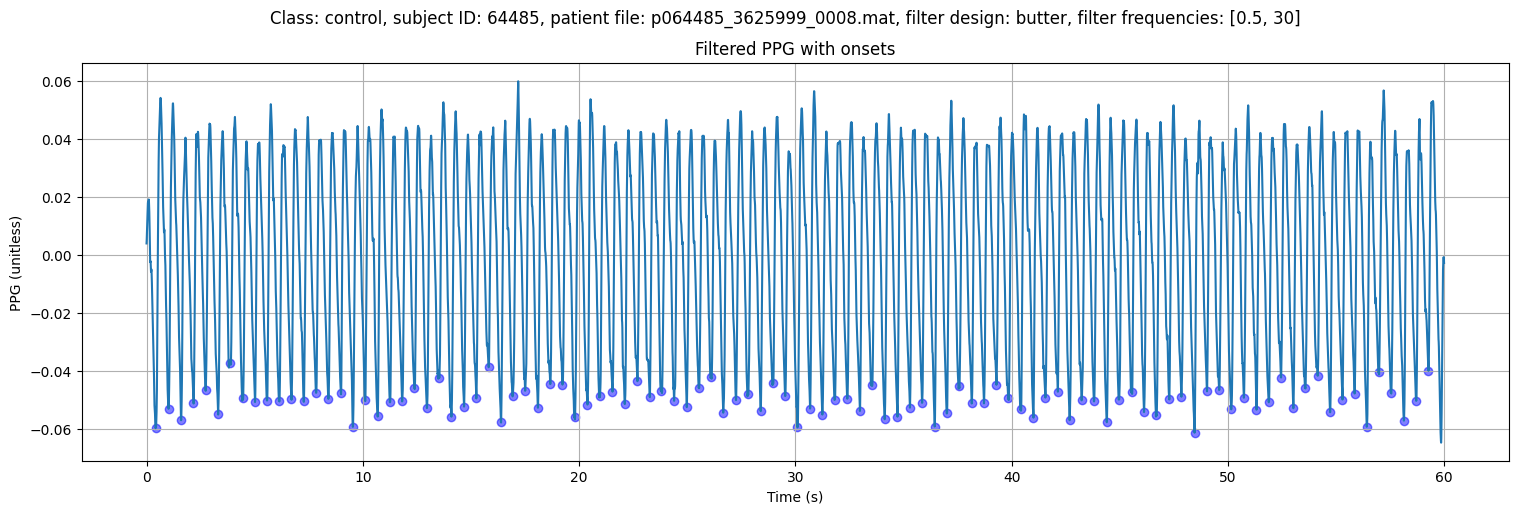

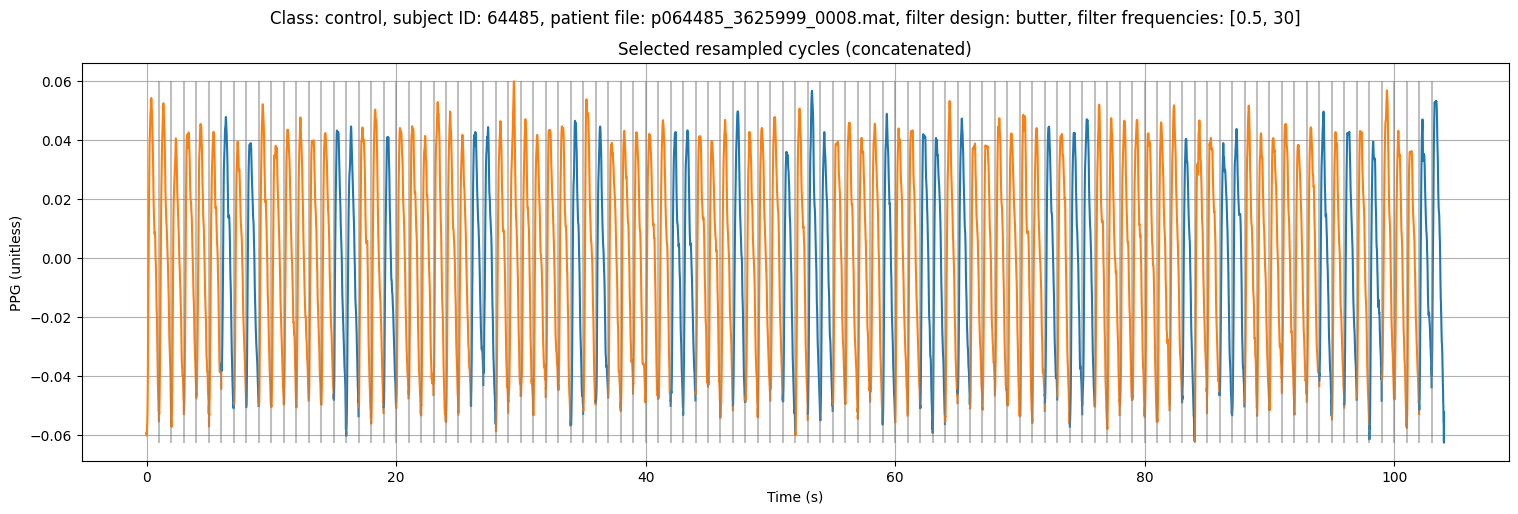

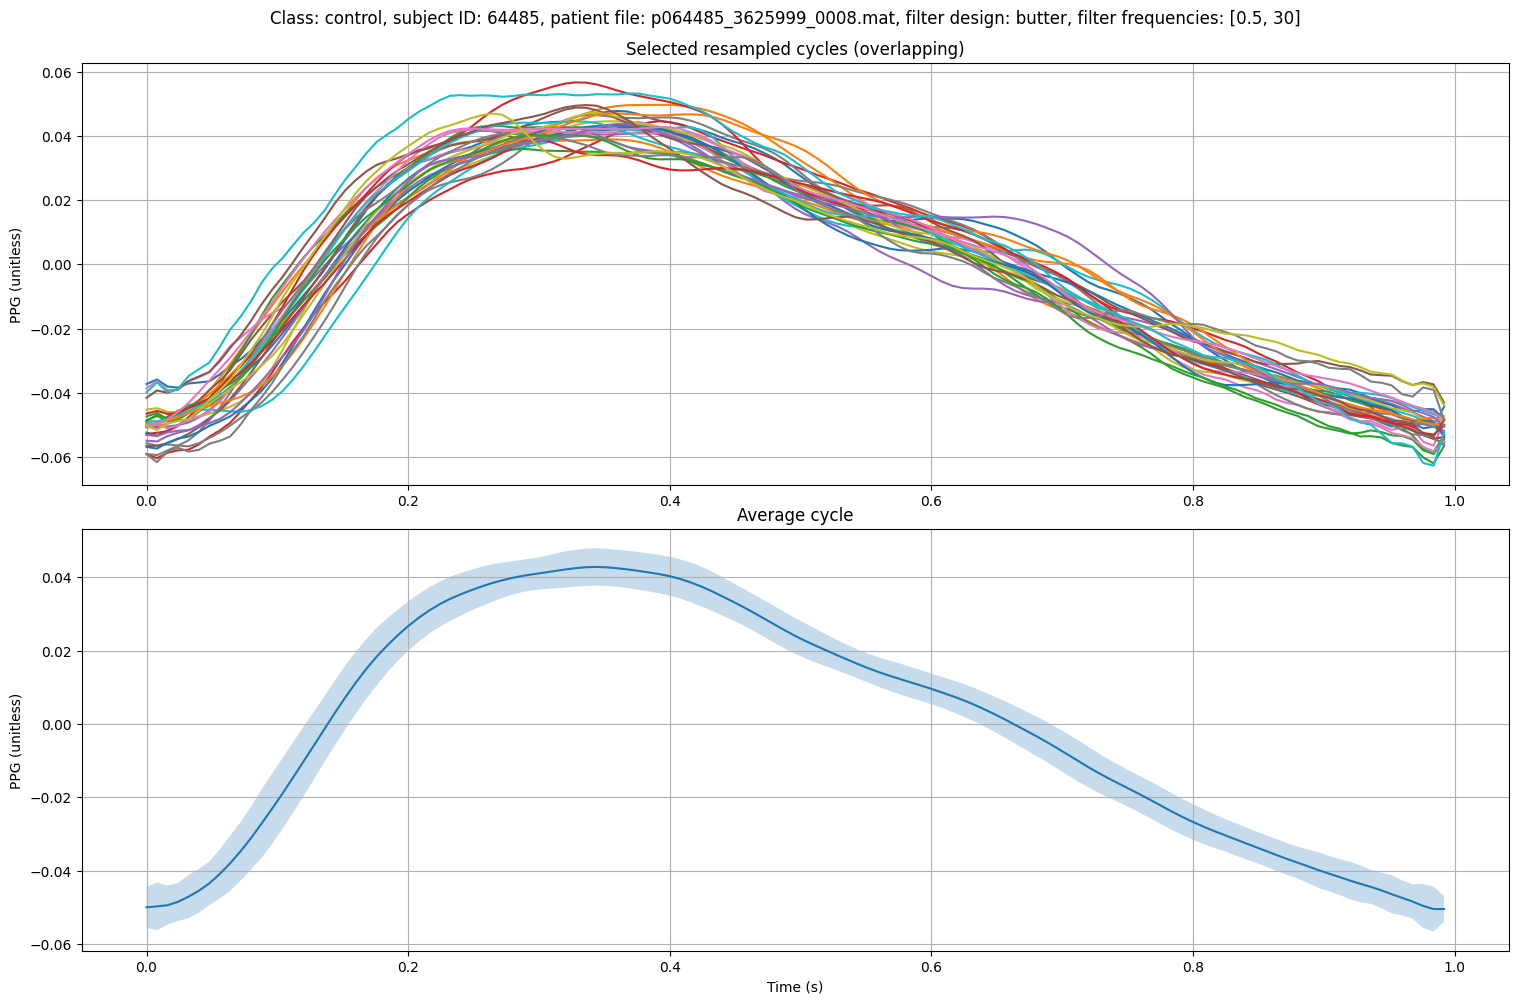

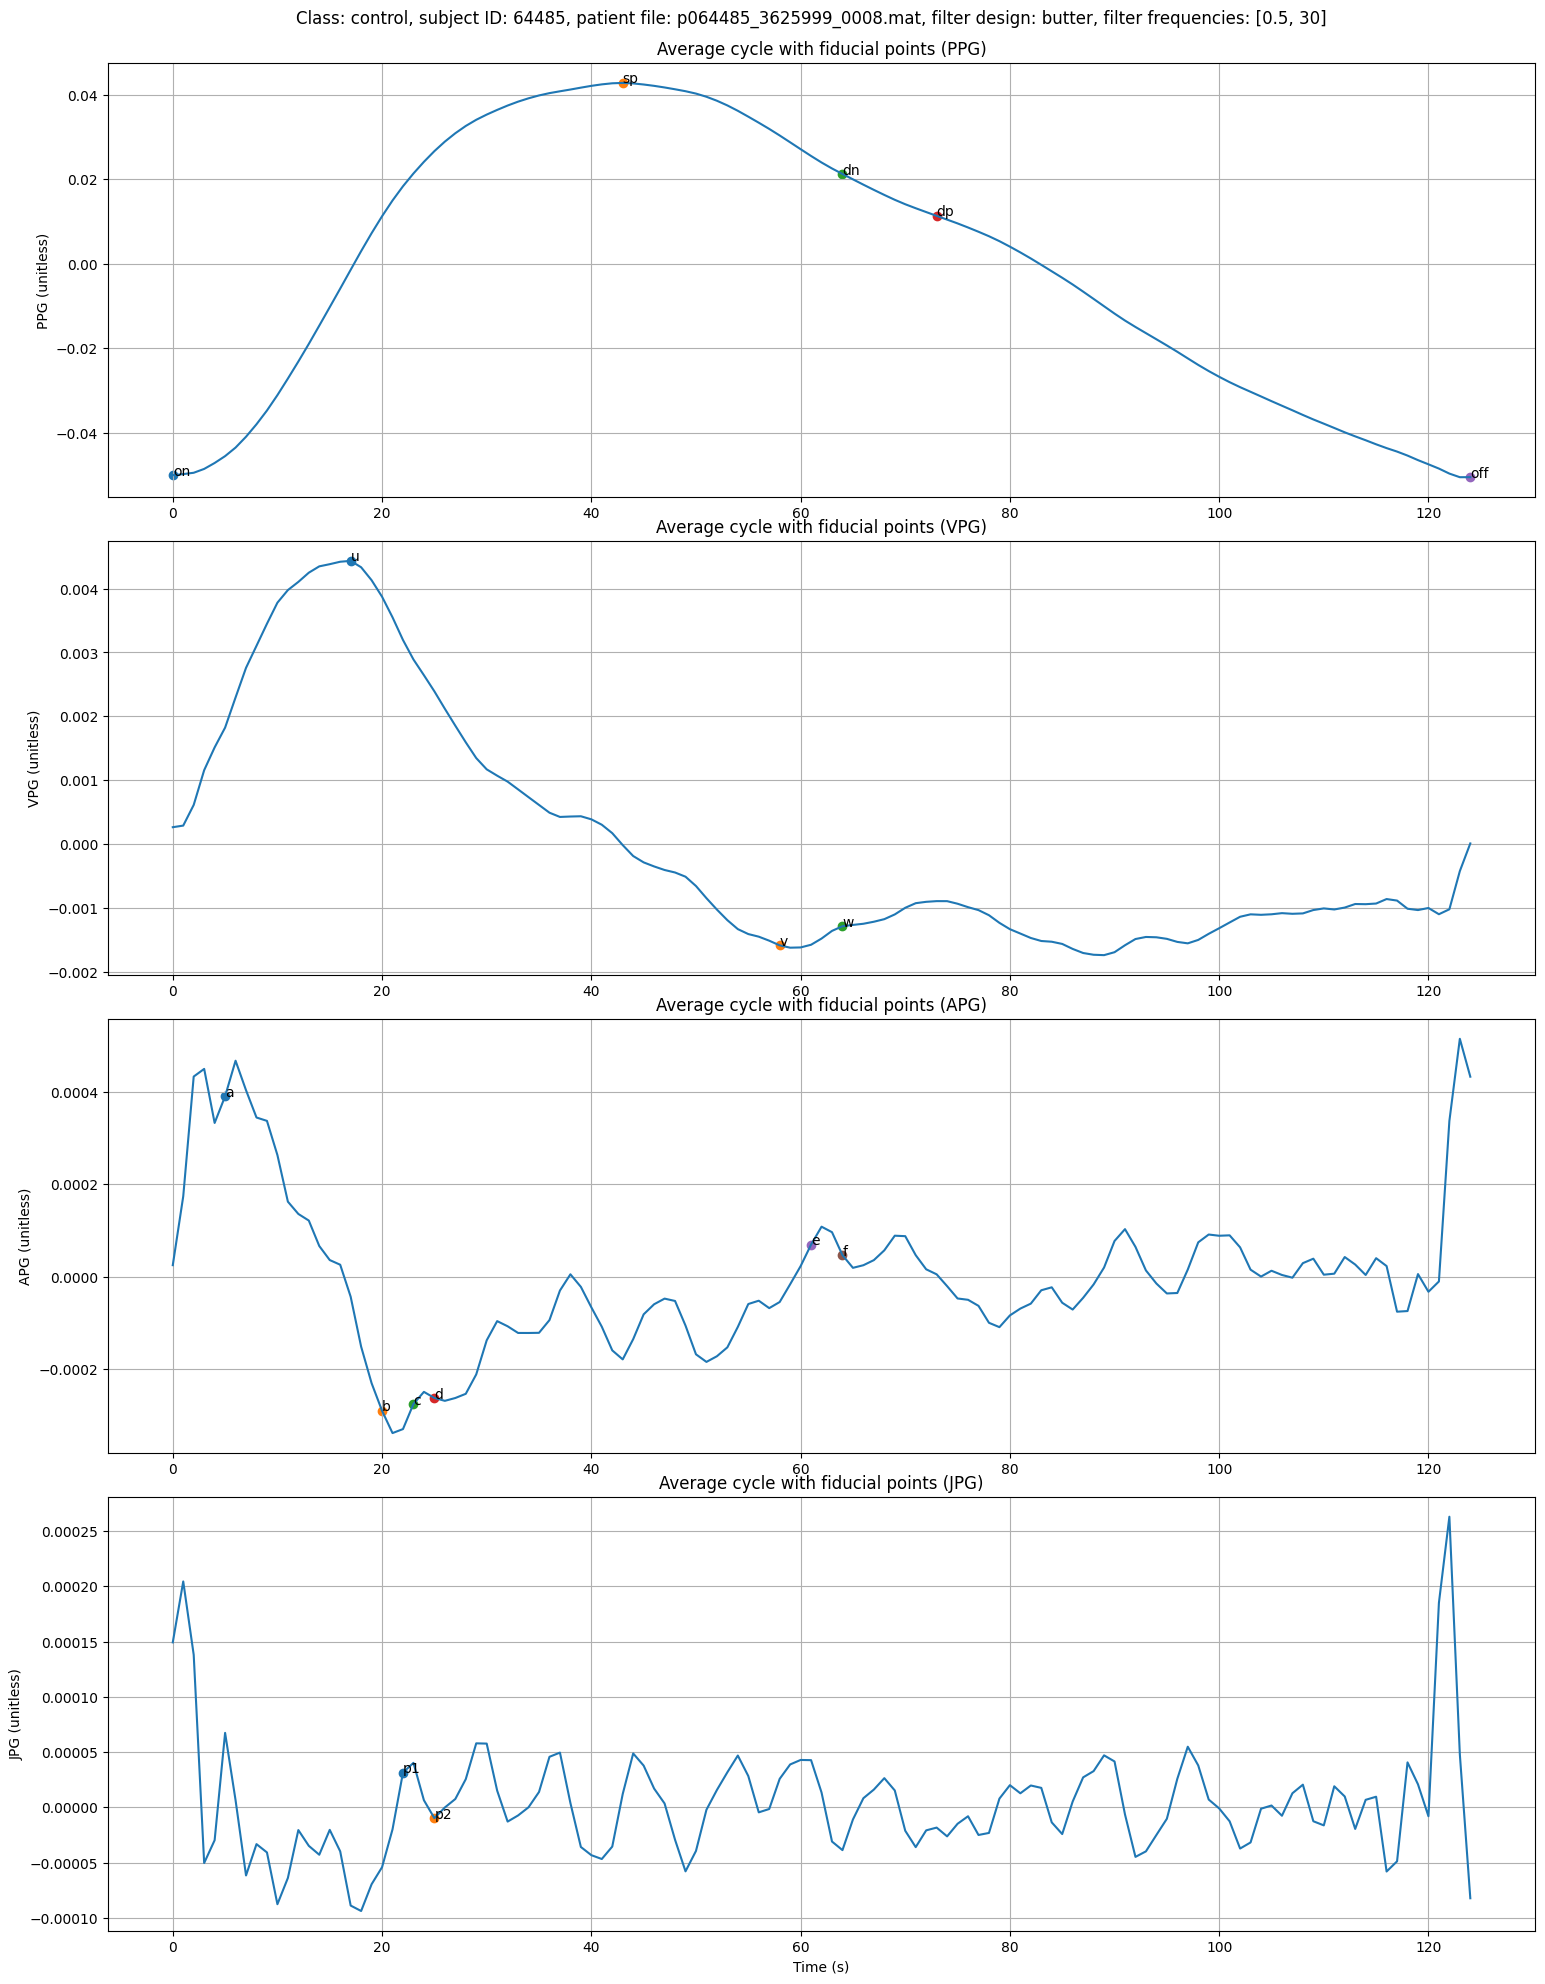

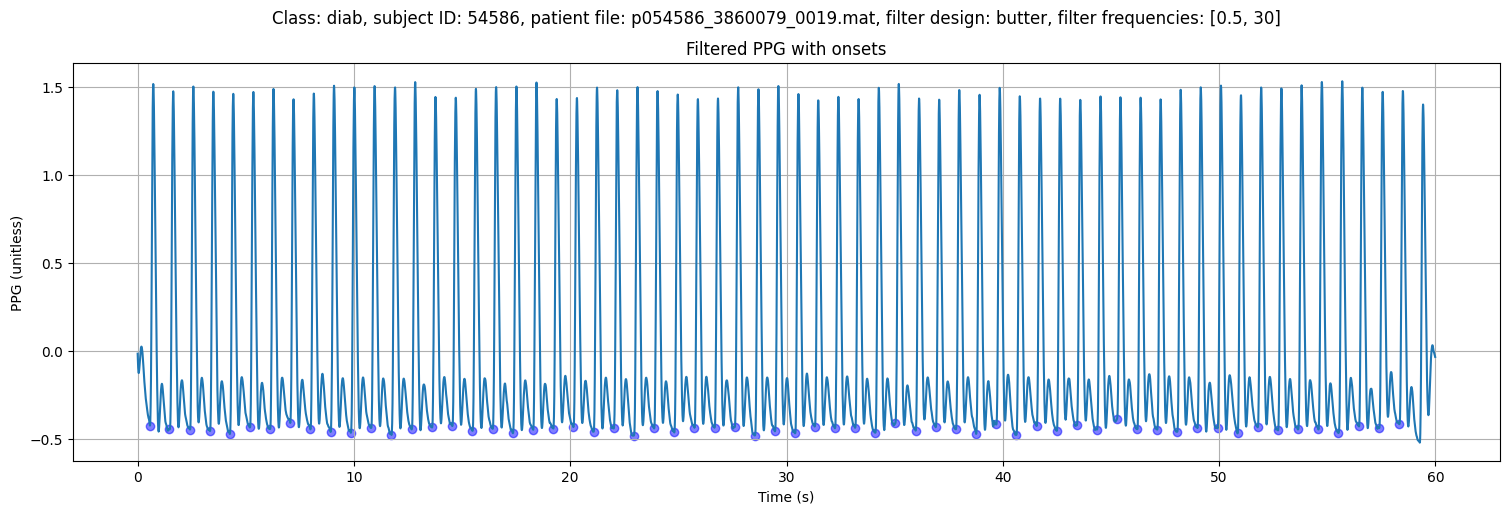

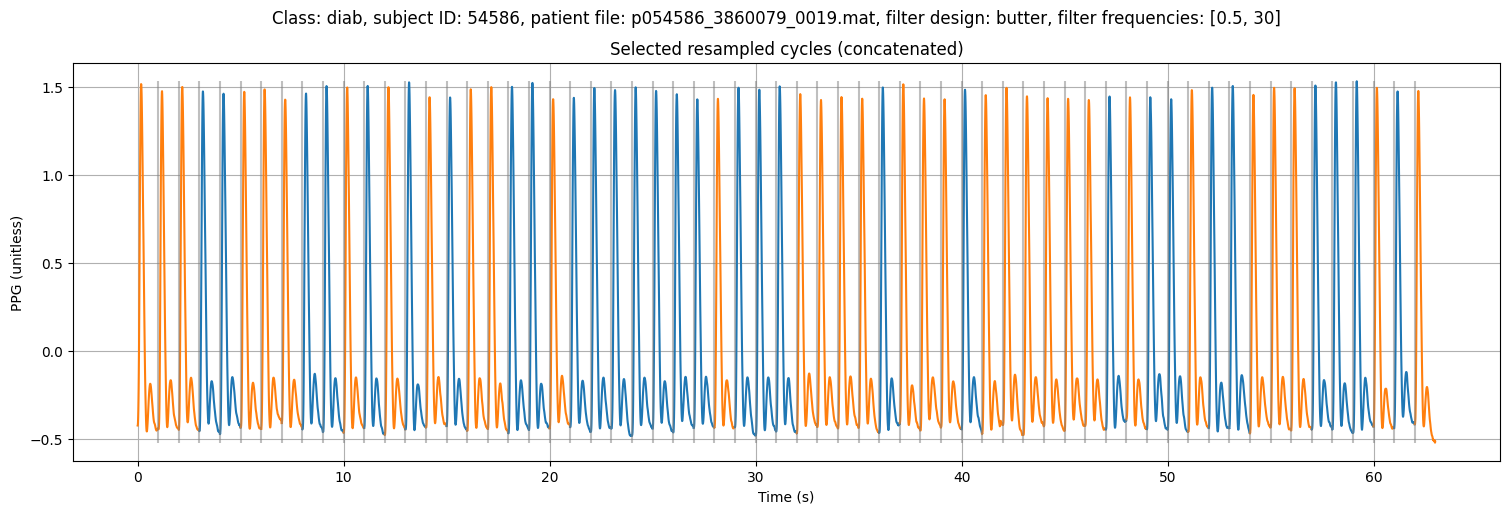

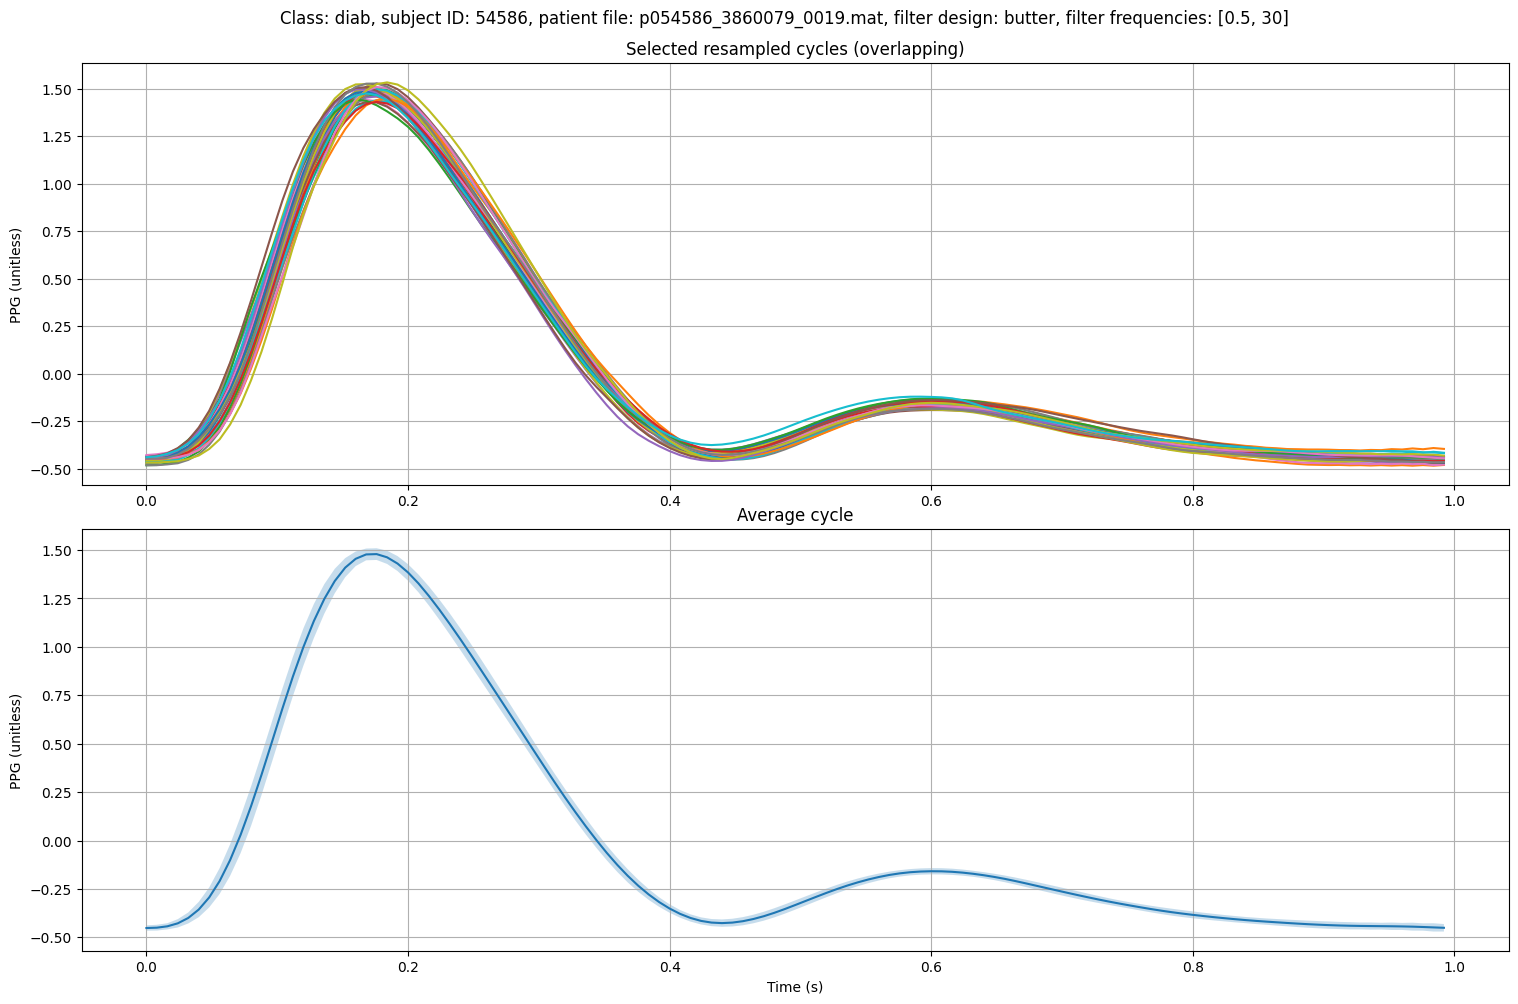

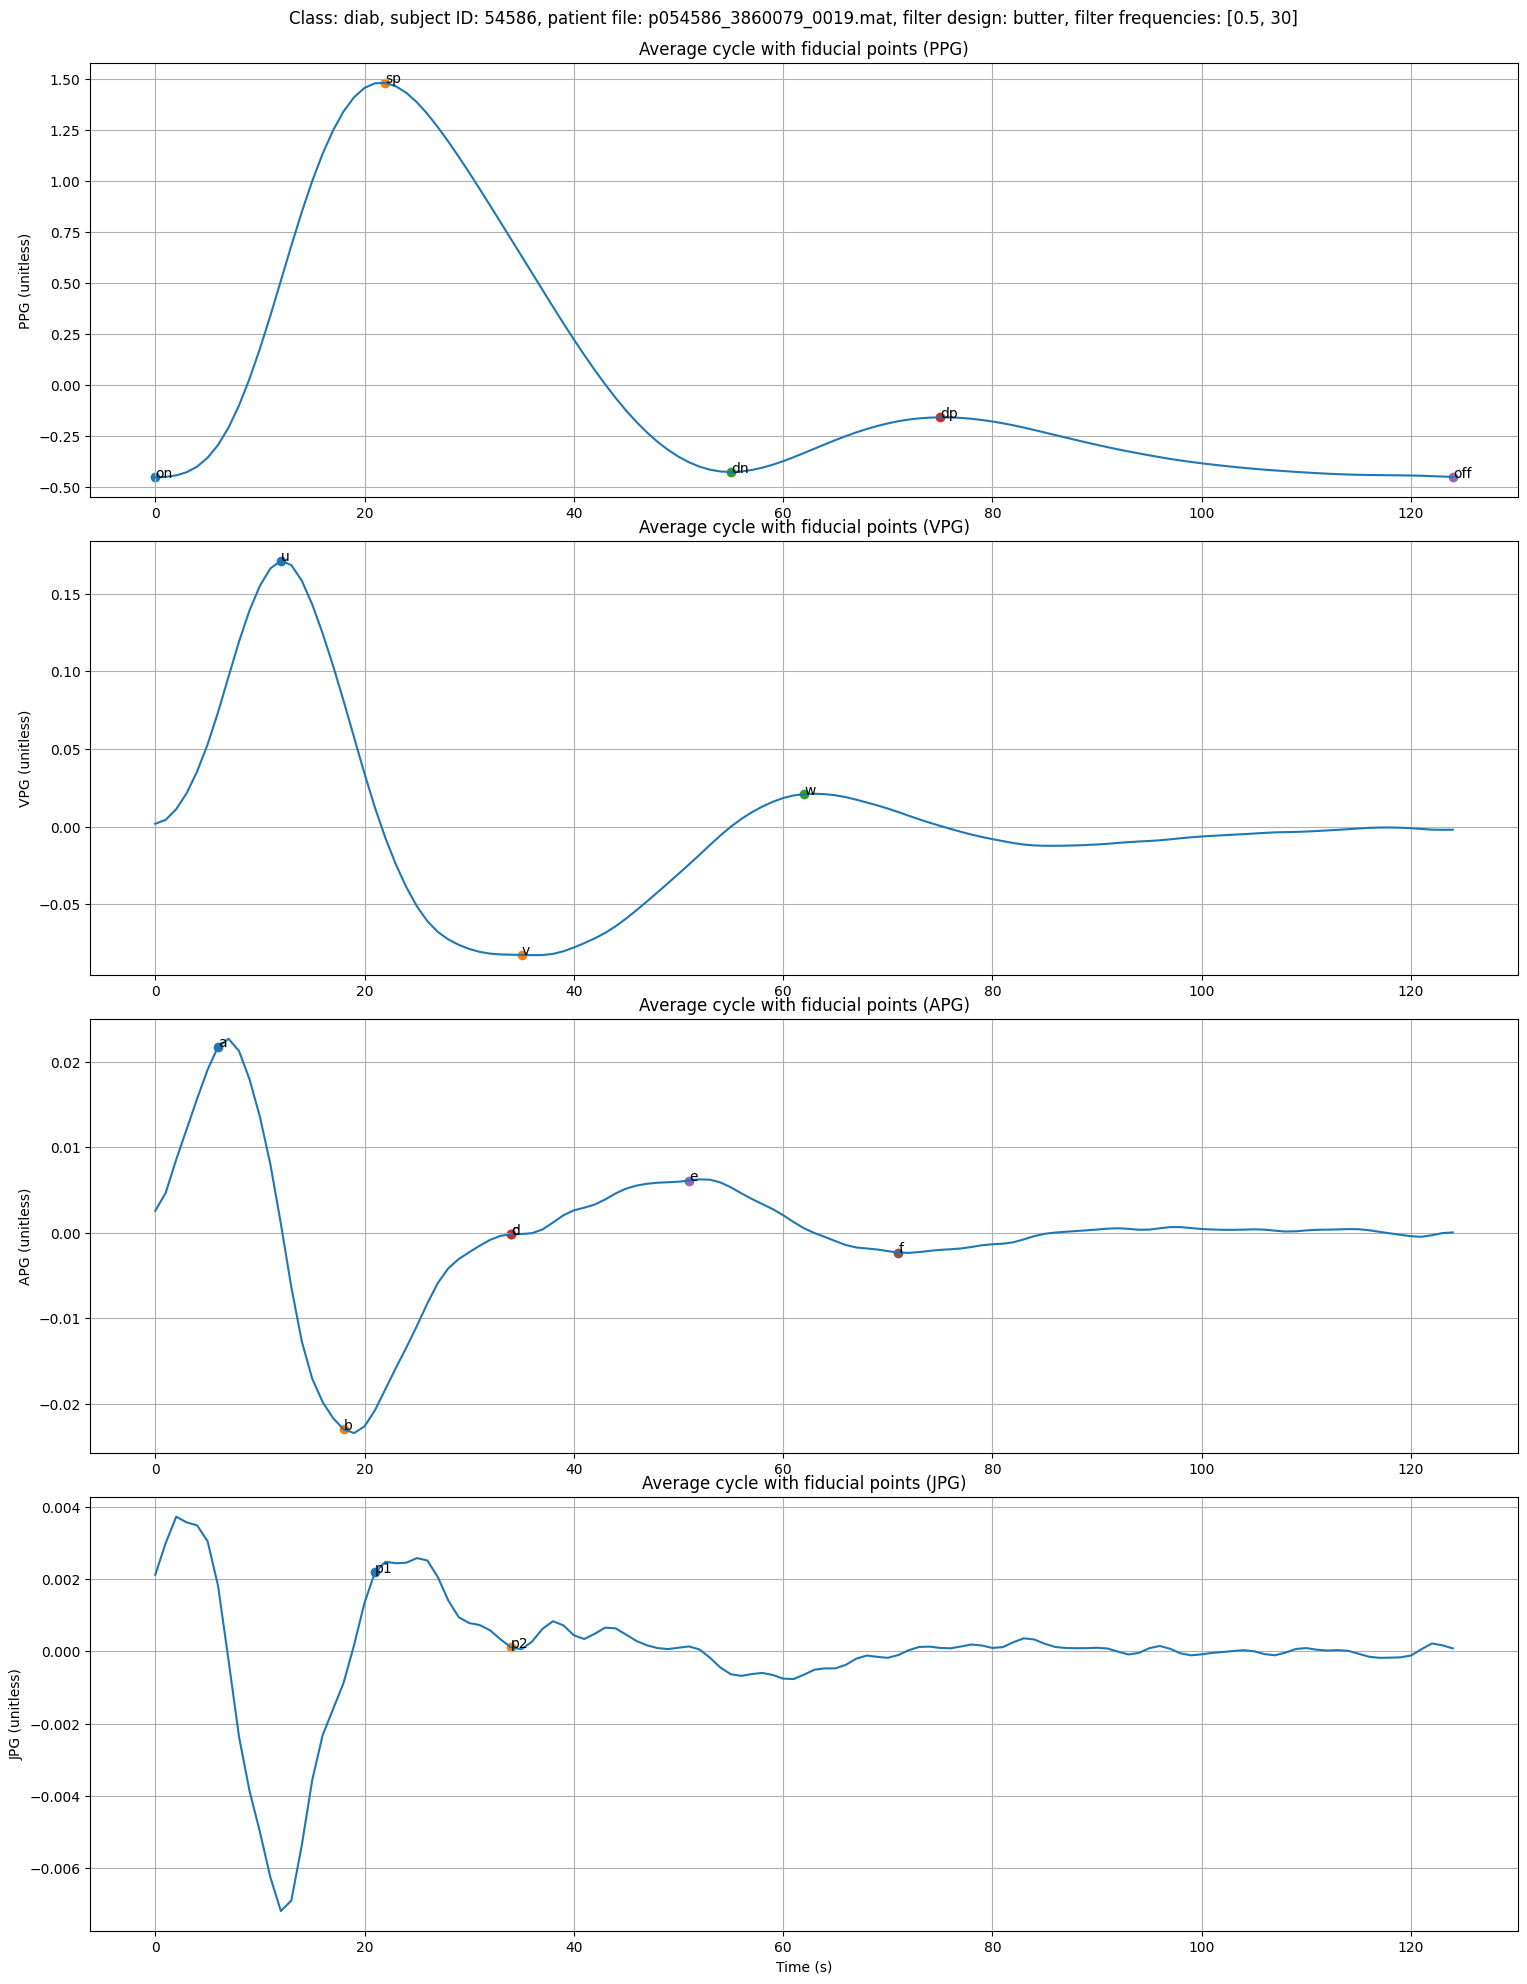

In [15]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
# wns = [[0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    # if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
    if subject_id not in [64485, 54586]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    # print(len(ppg_onsets))

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig_s, axes_s = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_s: tuple[plt.Axes]
    fig_s.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_s.tight_layout(rect=[0, 0, 1, 0.98])

    fig_r, axes_r = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_r: tuple[plt.Axes]
    fig_r.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_r.tight_layout(rect=[0, 0, 1, 0.98])

    fig_c, axes_c = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
    axes_c: tuple[plt.Axes]
    fig_c.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_c.tight_layout(rect=[0, 0, 1, 0.98])

    fig_d, axes_d = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))
    axes_d: tuple[plt.Axes]
    fig_d.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_d.tight_layout(rect=[0, 0, 1, 0.98])

    axes_s.plot(t - s0 / fs, ppg_filt)
    axes_s.scatter(t[df_cycles['on']] - s0 / fs, ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes_s.set_title('Filtered PPG with onsets')
    axes_s.set_xlabel('Time (s)')
    axes_s.set_ylabel('PPG (unitless)')
    axes_s.grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    # print(len(ppg_peaks) == len(cycles))

    cycles['peaks'] = ppg_peaks

    resampled_cycle_signals = []
    resampled_cycle_peaks = []
    for c, (on, off, peak) in enumerate(cycles.itertuples(index=False)):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        new_peak = int(round((c + (peak - on) / (off - on)) * fs))
        resampled_cycle_peaks.append(new_peak)
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_peaks = np.array(resampled_cycle_peaks)

    resampled_cycle_qualities_tm = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='templatematch')
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.mean(axis=1)

    # resampled_cycle_qualities_ho = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='ho2025')
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.reshape(resampled_cycle_signals.shape)
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.mean(axis=1)

    resampled_cycle_qualities_ds = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='dissimilarity')
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.mean(axis=1)

    # TODO: apply multiple quality filters and sorts

    # TODO: remove first and last cycles

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)
    # sorted_idxs = np.argsort(resampled_cycle_qualities_ds)[::-1]

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes_r.plot(time, signal, color='C0' if selected else 'C1')
    axes_r.vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes_r.set_title('Selected resampled cycles (concatenated)')
    axes_r.set_xlabel('Time (s)')
    axes_r.set_ylabel('PPG (unitless)')
    axes_r.grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes_c[0].plot(cycle_signal_time, signal)
    axes_c[0].set_title('Selected resampled cycles (overlapping)')
    axes_c[0].set_ylabel('PPG (unitless)')
    axes_c[0].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes_c[1].plot(cycle_signal_time, cycle_signal_mean)
    axes_c[1].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes_c[1].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes_c[1].set_title('Average cycle')
    axes_c[1].set_xlabel('Time (s)')
    axes_c[1].set_ylabel('PPG (unitless)')
    axes_c[1].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            peaks=peaks,
            onsets=onsets,
            # smoothing=True,
            # sm_wins={'ppg': 30},
            # savgol=True,
            # sg_win=15,
            # sg_poly=3,
            check_ppg_len=False,
        )

    t_pts = fp.get_fp()

    # for c in t_pts.index:
    #     # for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
    #     #     t_pts[m][c] += 0
    #     # for n, m in enumerate(['u', 'v', 'w']):
    #     #     t_pts[m][c] += 0
    #     for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
    #         t_pts.loc[c, m] += 1
    #     for n, m in enumerate(['p1', 'p2']):
    #         t_pts.loc[c, m] += 1

    # axes_d[0].plot(cycle_signal_mean)
    axes_d[0].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes_d[0].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes_d[0].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes_d[0].set_title('Average cycle with fiducial points (PPG)')
    # axes_d[0].set_xlabel('Time (s)')
    axes_d[0].set_ylabel('PPG (unitless)')
    axes_d[0].grid()

    axes_d[1].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes_d[1].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes_d[1].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes_d[1].set_title('Average cycle with fiducial points (VPG)')
    # axes_d[1].set_xlabel('Time (s)')
    axes_d[1].set_ylabel('VPG (unitless)')
    axes_d[1].grid()

    axes_d[2].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes_d[2].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes_d[2].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes_d[2].set_title('Average cycle with fiducial points (APG)')
    # axes_d[2].set_xlabel('Time (s)')
    axes_d[2].set_ylabel('APG (unitless)')
    axes_d[2].grid()

    axes_d[3].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes_d[3].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes_d[3].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes_d[3].set_title('Average cycle with fiducial points (JPG)')
    axes_d[3].set_xlabel('Time (s)')
    axes_d[3].set_ylabel('JPG (unitless)')
    axes_d[3].grid()

    # fig_s.savefig(f'images/doc/{subject_id}_signal.png')
    # fig_r.savefig(f'images/doc/{subject_id}_resampled.png')
    # fig_c.savefig(f'images/doc/{subject_id}_cycle.png')
    fig_d.savefig(f'images/doc/{subject_id}_points_old.pdf')

  0%|          | 0/34 [00:00<?, ?it/s]

AAAAAAAAAAAAAAAAAAAAAAAAAA
ppg_onsets: [  53  127  200  271  341  413  485  556  627  696  767  837  908  980
 1051 1123 1192 1263 1335 1407 1477 1548 1621 1692 1762 1835 1906 1977
 2048 2116 2188 2262 2333 2404 2474 2548 2619 2693 2764 2837 2909 2975
 3049 3122 3193 3263 3333 3407 3476 3550 3620 3691 3762 3835 3906 3978
 4050 4123 4191 4266 4340 4412 4482 4555 4625 4696 4769 4840 4912 4981
 5052 5126 5195 5267 5335 5405 5476 5550 5619 5693 5765 5836 5911 5981
 6057 6129 6199 6269 6342 6415 6486 6557 6628 6698 6769 6840 6912 6982
 7052 7121 7192 7267 7338 7409 7480]
ppg_peaks: [  53  127  200  271  341  413  485  556  627  696  767  837  908  980
 1051 1123 1192 1263 1335 1407 1477 1548 1621 1692 1762 1835 1906 1977
 2048 2116 2188 2262 2333 2404 2474 2548 2619 2693 2764 2837 2909 2975
 3049 3122 3193 3263 3333 3407 3476 3550 3620 3691 3762 3835 3906 3978
 4050 4123 4191 4266 4340 4412 4482 4555 4625 4696 4769 4840 4912 4981
 5052 5126 5195 5267 5335 5405 5476 5550 5619 5693 5765 5836 

  9%|▉         | 3/34 [00:01<00:12,  2.56it/s]

AAAAAAAAAAAAAAAAAAAAAAAAAA
ppg_onsets: [  71  184  303  418  533  648  766  882  998 1115 1232 1350 1467 1583
 1701 1819 1935 2052 2169 2286 2402 2518 2635 2751 2868 2985 3101 3218
 3334 3451 3567 3683 3800 3913 4030 4146 4263 4379 4496 4612 4729 4846
 4961 5078 5195 5312 5427 5544 5659 5778 5892 6007 6125 6242 6357 6473
 6591 6706 6824 6940 7059 7176 7292 7410]
ppg_peaks: [  71  184  303  418  533  648  766  882  998 1115 1232 1350 1467 1583
 1701 1819 1935 2052 2169 2286 2402 2518 2635 2751 2868 2985 3101 3218
 3334 3451 3567 3683 3800 3913 4030 4146 4263 4379 4496 4612 4729 4846
 4961 5078 5195 5312 5427 5544 5659 5778 5892 6007 6125 6242 6357 6473
 6591 6706 6824 6940 7059 7176 7292 7410]
ppg_peaks filtered: [  71  184  303  418  533  648  766  882  998 1115 1232 1350 1467 1583
 1701 1819 1935 2052 2169 2286 2402 2518 2635 2751 2868 2985 3101 3218
 3334 3451 3567 3683 3800 3913 4030 4146 4263 4379 4496 4612 4729 4846
 4961 5078 5195 5312 5427 5544 5659 5778 5892 6007 6125 6242 6357

100%|██████████| 34/34 [00:01<00:00, 17.12it/s]


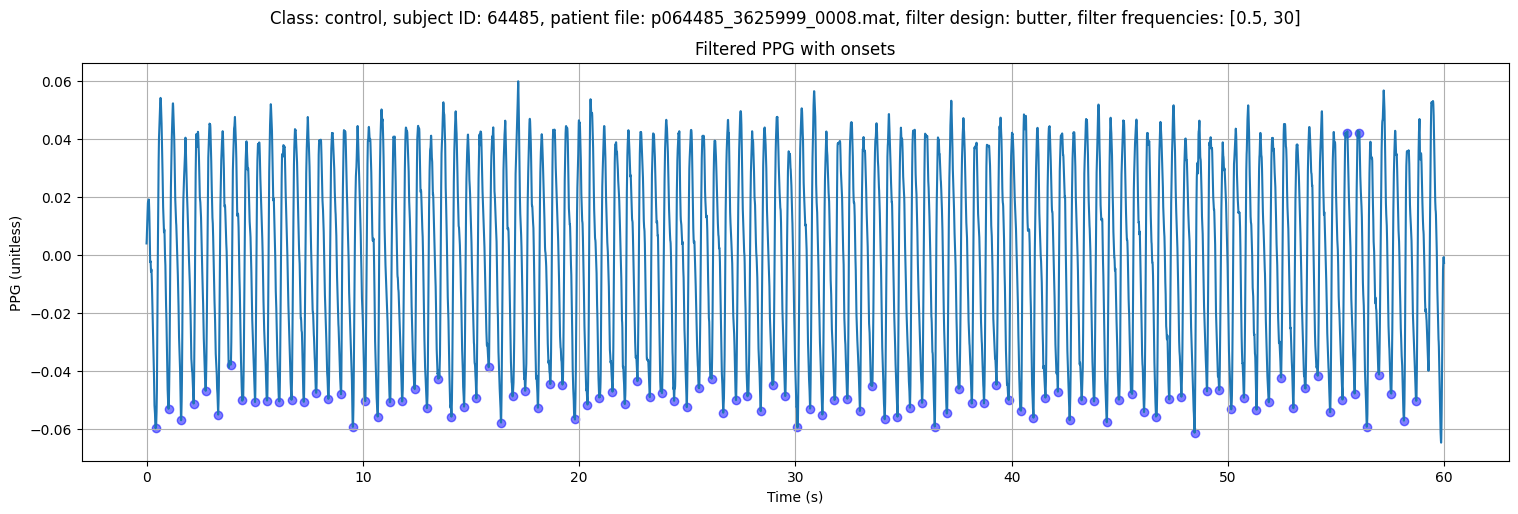

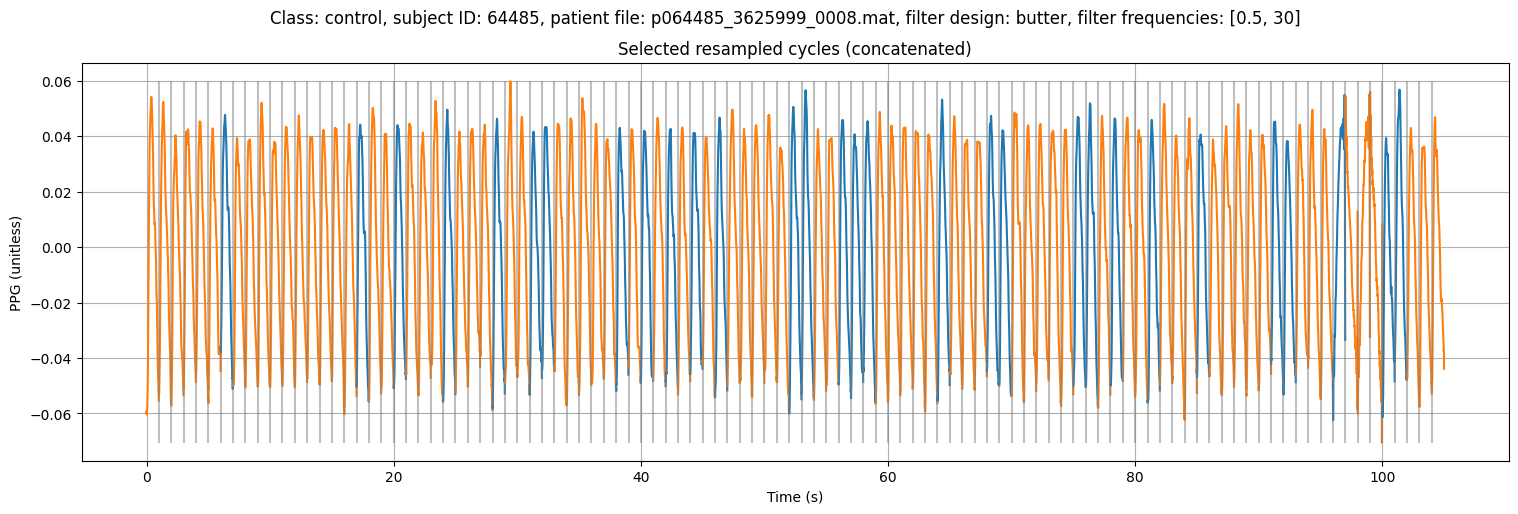

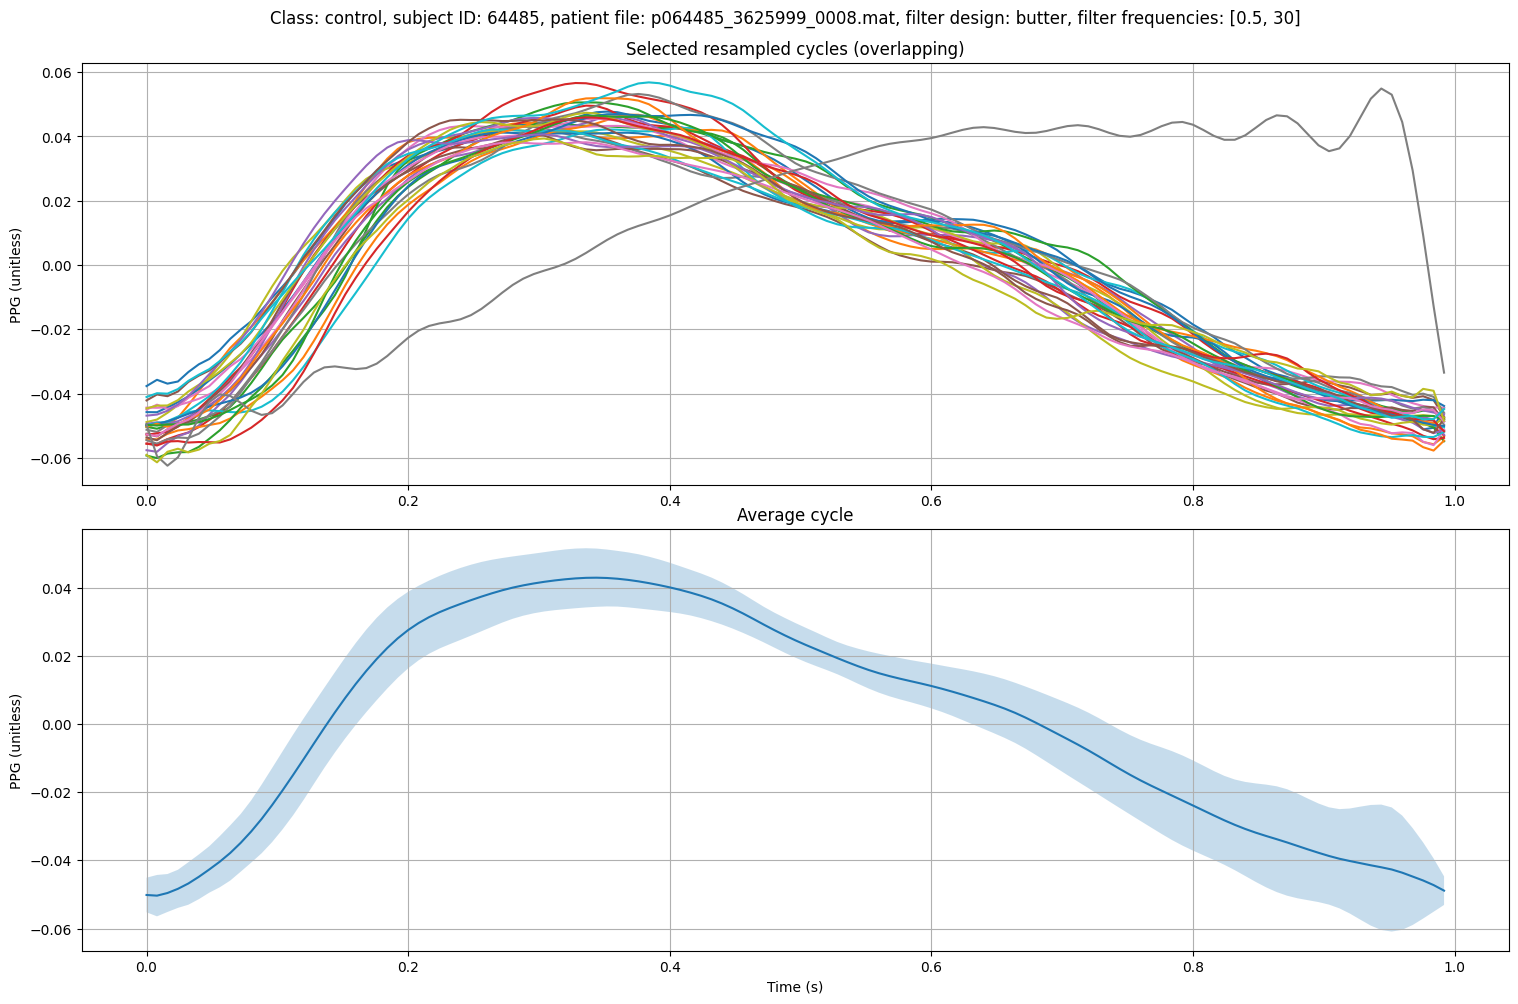

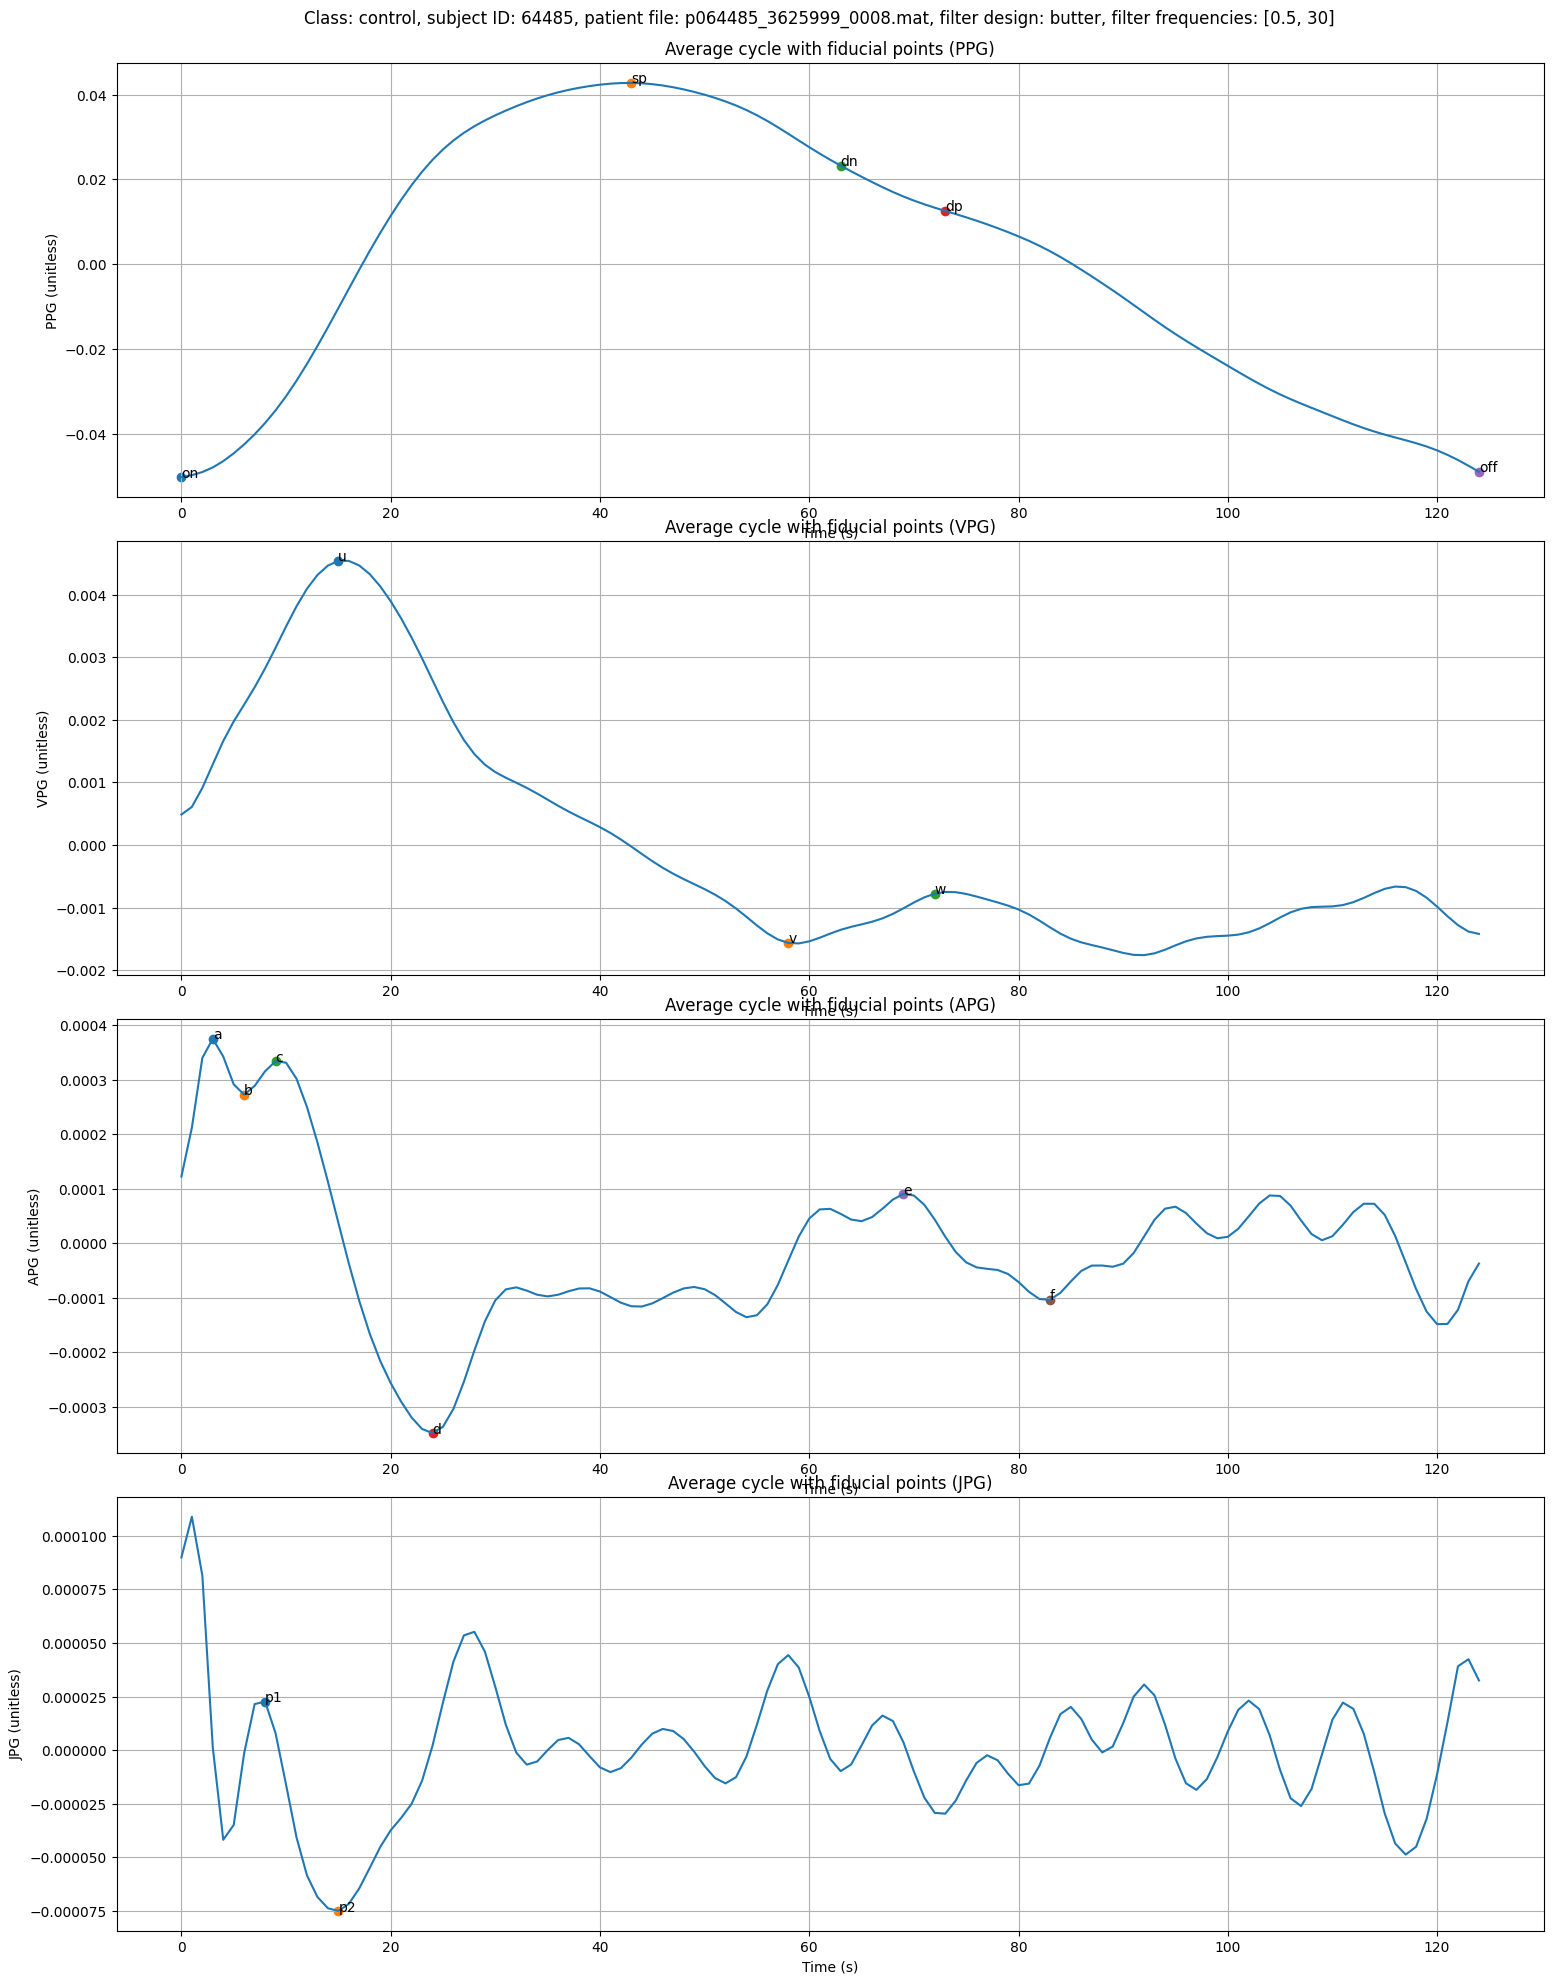

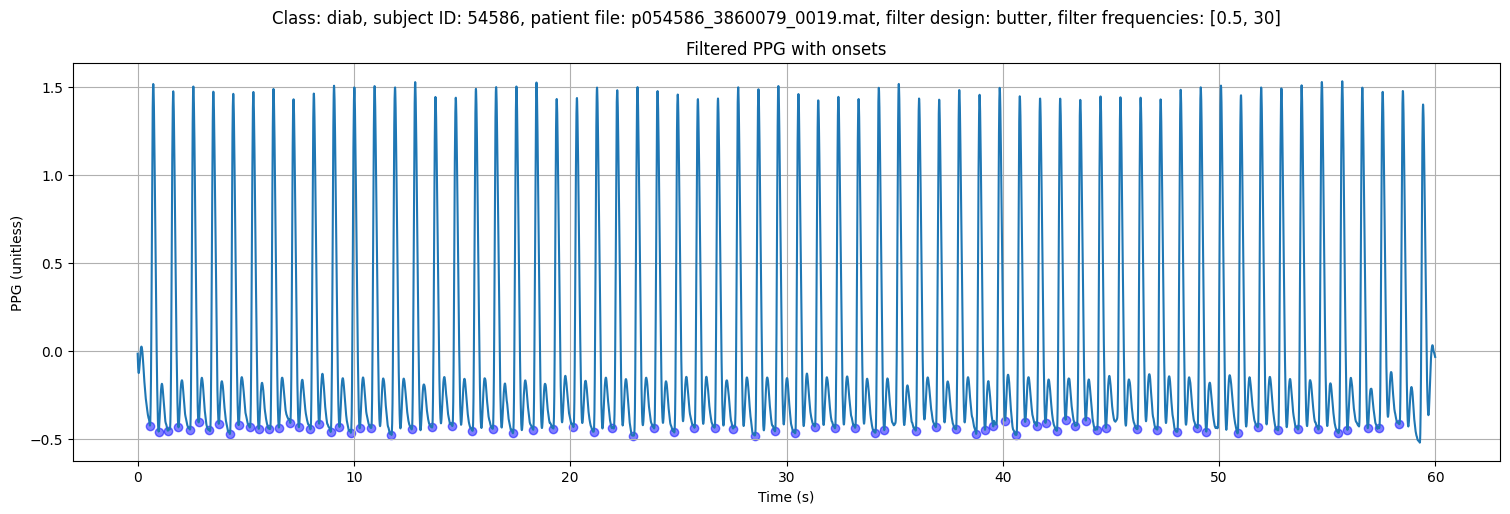

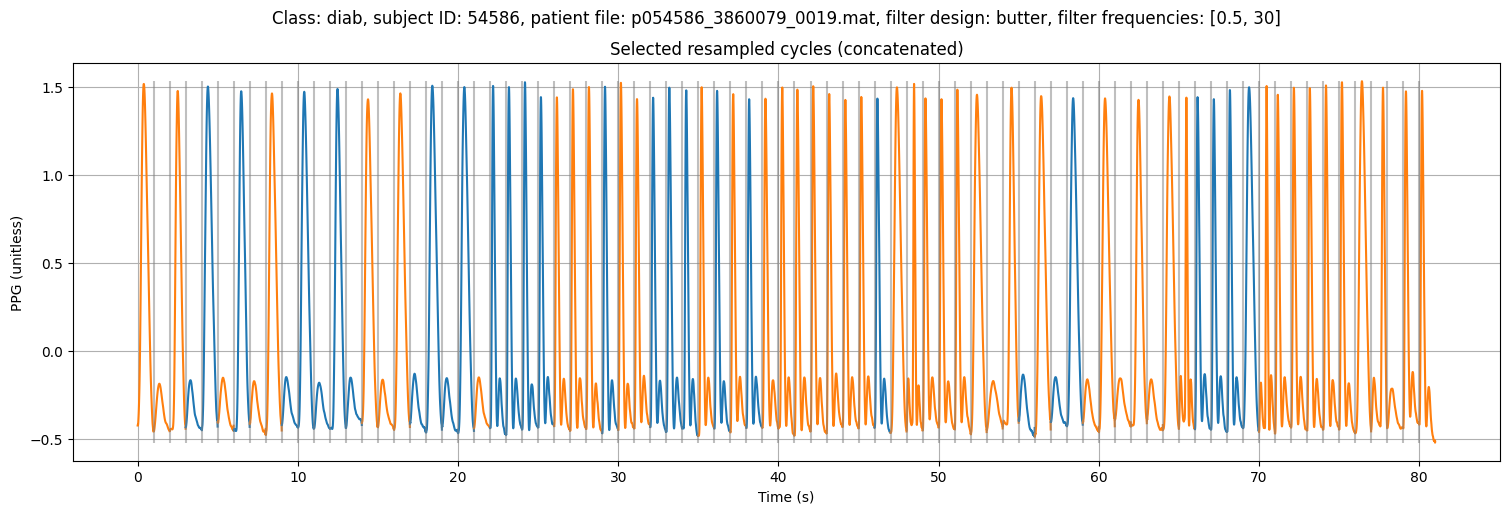

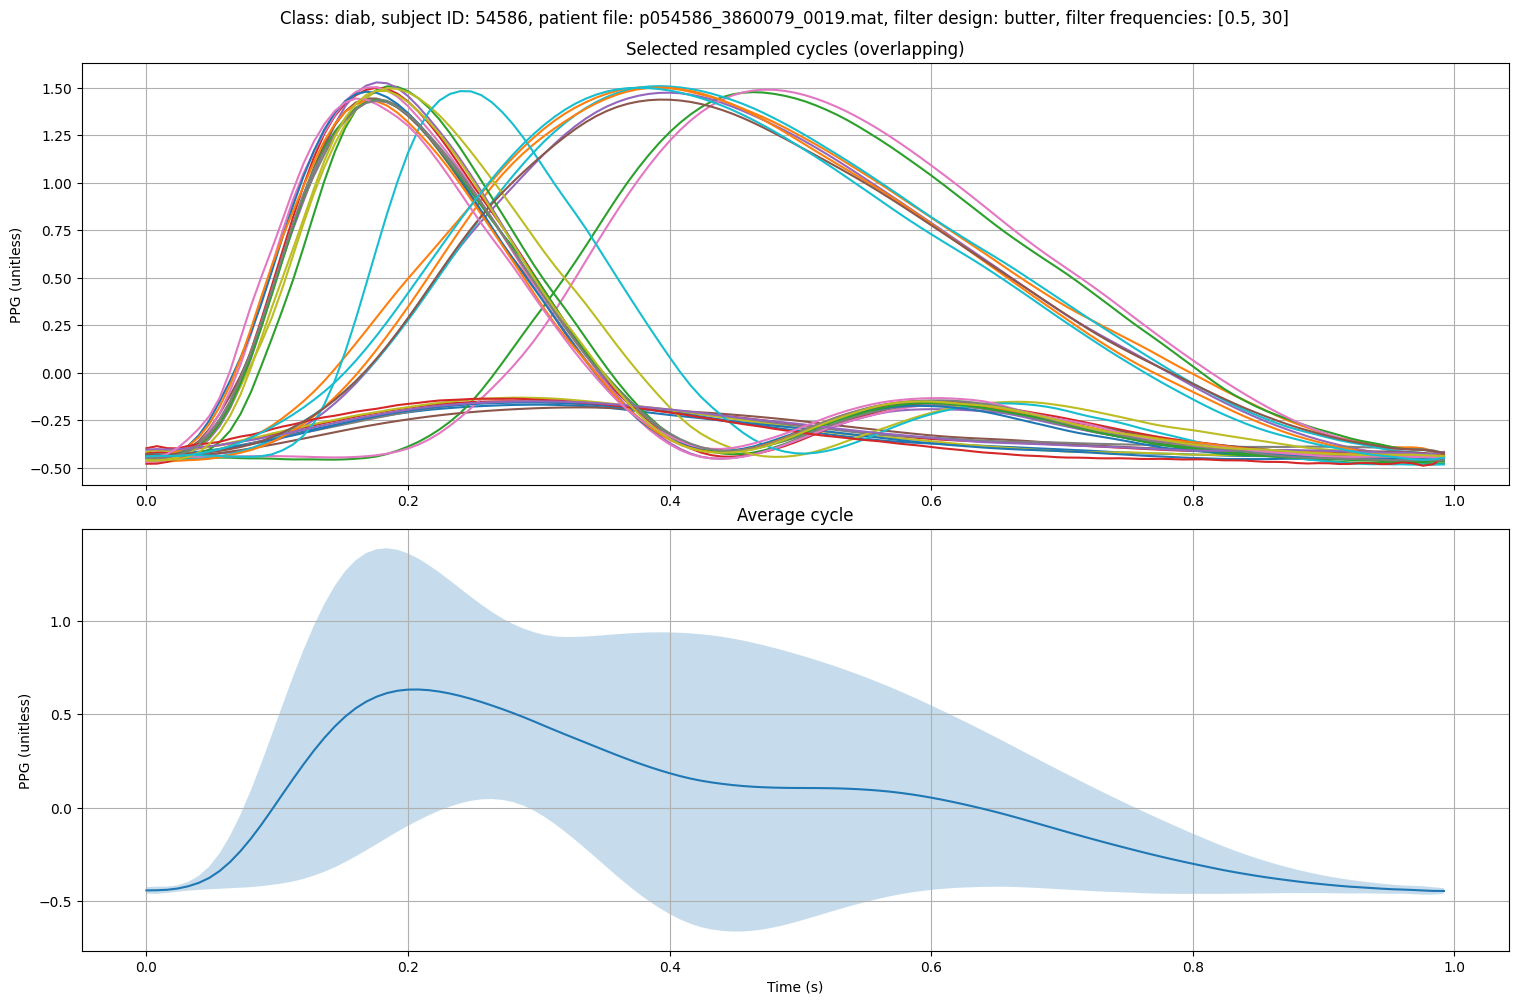

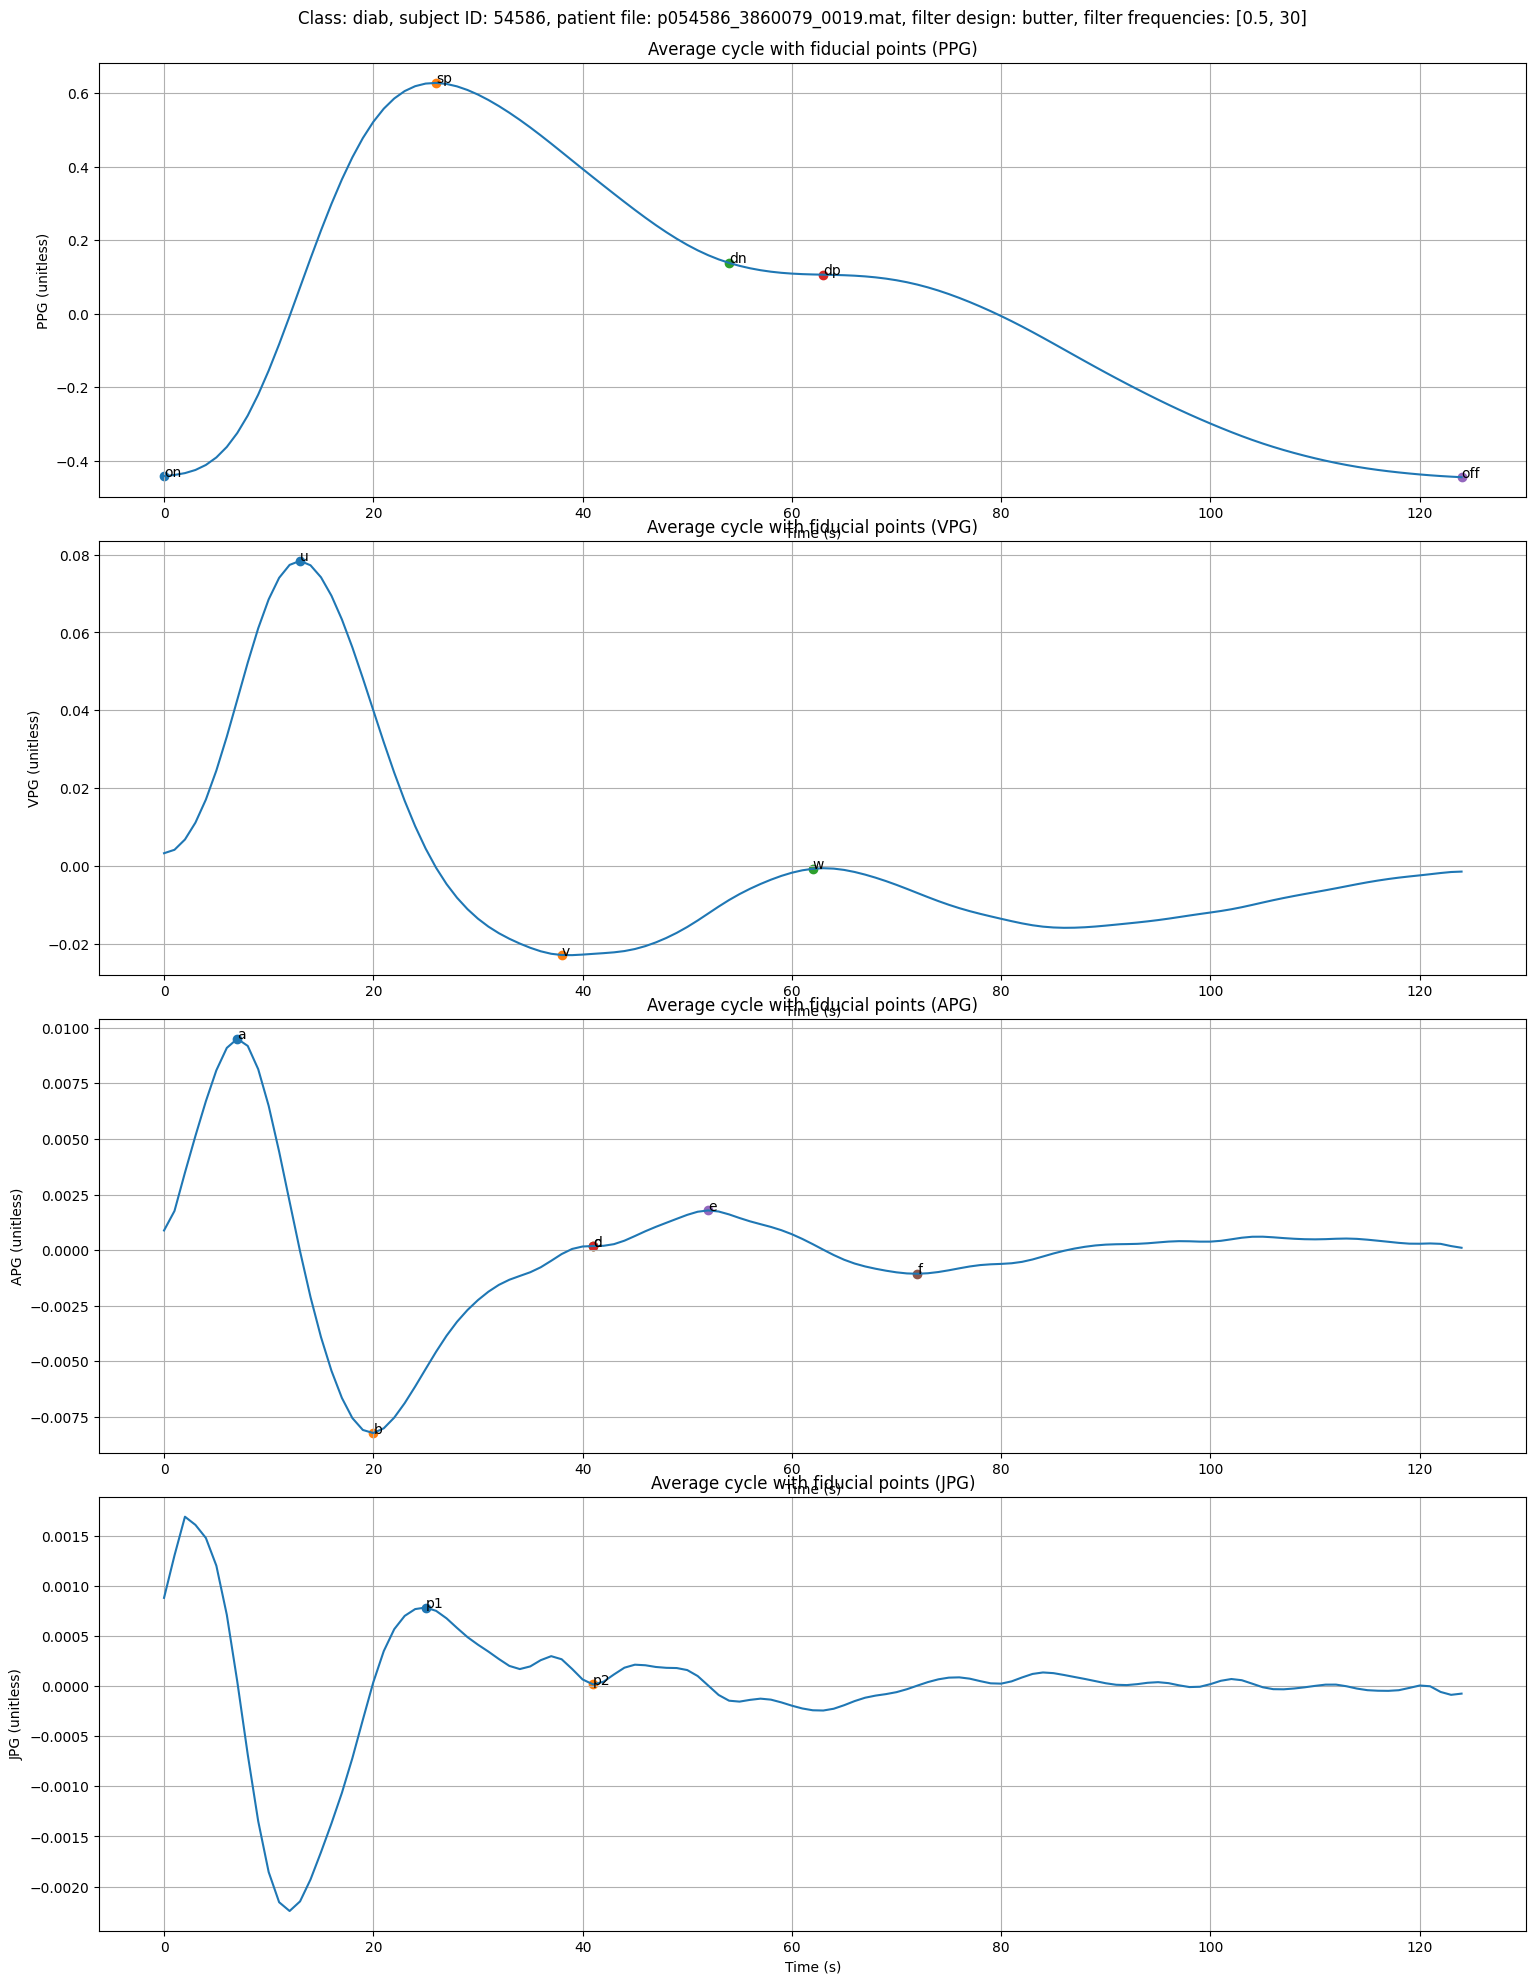

In [21]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
# wns = [[0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    # if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
    if subject_id not in [64485, 54586]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    print('AAAAAAAAAAAAAAAAAAAAAAAAAA')

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    print('ppg_onsets:', ppg_onsets)

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    print('ppg_peaks:', ppg_onsets)

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    print('ppg_peaks filtered:', ppg_onsets)

    print('BBBBBBBBBBBBBBBBBBBBBBBBBB')

    _ppg_peaks, ppg_info = nk.ppg.ppg_peaks(ppg_cleaned=ppg_filt, sampling_rate=fs, method='charlton')

    ppg_peaks = ppg_info['PPG_Peaks']

    print('ppg_peaks:', ppg_peaks)

    ppg_onsets = ppg_info['PPG_Onsets']

    print('ppg_onsets:', ppg_onsets)

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    print('ppg_peaks filtered:', ppg_peaks)

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig_s, axes_s = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_s: tuple[plt.Axes]
    fig_s.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_s.tight_layout(rect=[0, 0, 1, 0.98])

    fig_r, axes_r = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_r: tuple[plt.Axes]
    fig_r.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_r.tight_layout(rect=[0, 0, 1, 0.98])

    fig_c, axes_c = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
    axes_c: tuple[plt.Axes]
    fig_c.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_c.tight_layout(rect=[0, 0, 1, 0.98])

    fig_d, axes_d = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))
    axes_d: tuple[plt.Axes]
    fig_d.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_d.tight_layout(rect=[0, 0, 1, 0.98])

    axes_s.plot(t - s0 / fs, ppg_filt)
    axes_s.scatter(t[df_cycles['on']] - s0 / fs, ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes_s.set_title('Filtered PPG with onsets')
    axes_s.set_xlabel('Time (s)')
    axes_s.set_ylabel('PPG (unitless)')
    axes_s.grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    # print(len(ppg_peaks) == len(cycles))

    cycles['peaks'] = ppg_peaks

    resampled_cycle_signals = []
    resampled_cycle_peaks = []
    for c, (on, off, peak) in enumerate(cycles.itertuples(index=False)):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        new_peak = int(round((c + (peak - on) / (off - on)) * fs))
        resampled_cycle_peaks.append(new_peak)
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_peaks = np.array(resampled_cycle_peaks)

    resampled_cycle_qualities_tm = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='templatematch')
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.mean(axis=1)

    # resampled_cycle_qualities_ho = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='ho2025')
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.reshape(resampled_cycle_signals.shape)
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.mean(axis=1)

    resampled_cycle_qualities_ds = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='dissimilarity')
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.mean(axis=1)

    # TODO: apply multiple quality filters and sorts

    # TODO: remove first and last cycles

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)
    # sorted_idxs = np.argsort(resampled_cycle_qualities_ds)[::-1]

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes_r.plot(time, signal, color='C0' if selected else 'C1')
    axes_r.vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes_r.set_title('Selected resampled cycles (concatenated)')
    axes_r.set_xlabel('Time (s)')
    axes_r.set_ylabel('PPG (unitless)')
    axes_r.grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes_c[0].plot(cycle_signal_time, signal)
    axes_c[0].set_title('Selected resampled cycles (overlapping)')
    axes_c[0].set_ylabel('PPG (unitless)')
    axes_c[0].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes_c[1].plot(cycle_signal_time, cycle_signal_mean)
    axes_c[1].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes_c[1].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes_c[1].set_title('Average cycle')
    axes_c[1].set_xlabel('Time (s)')
    axes_c[1].set_ylabel('PPG (unitless)')
    axes_c[1].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            peaks=peaks,
            onsets=onsets,
            smoothing=True,
            sm_wins={'ppg': 30},
            # savgol=True,
            # sg_win=15,
            # sg_poly=3,
            check_ppg_len=False,
        )

    t_pts = fp.get_fp()

    for c in t_pts.index:
        # for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
        #     t_pts[m][c] += 0
        # for n, m in enumerate(['u', 'v', 'w']):
        #     t_pts[m][c] += 0
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            t_pts.loc[c, m] += 1
        for n, m in enumerate(['p1', 'p2']):
            t_pts.loc[c, m] += 1

    # axes_d[0].plot(cycle_signal_mean)
    axes_d[0].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes_d[0].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes_d[0].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes_d[0].set_title('Average cycle with fiducial points (PPG)')
    axes_d[0].set_xlabel('Time (s)')
    axes_d[0].set_ylabel('PPG (unitless)')
    axes_d[0].grid()

    axes_d[1].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes_d[1].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes_d[1].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes_d[1].set_title('Average cycle with fiducial points (VPG)')
    axes_d[1].set_xlabel('Time (s)')
    axes_d[1].set_ylabel('VPG (unitless)')
    axes_d[1].grid()

    axes_d[2].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes_d[2].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes_d[2].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes_d[2].set_title('Average cycle with fiducial points (APG)')
    axes_d[2].set_xlabel('Time (s)')
    axes_d[2].set_ylabel('APG (unitless)')
    axes_d[2].grid()

    axes_d[3].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes_d[3].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes_d[3].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes_d[3].set_title('Average cycle with fiducial points (JPG)')
    axes_d[3].set_xlabel('Time (s)')
    axes_d[3].set_ylabel('JPG (unitless)')
    axes_d[3].grid()

    # fig_s.savefig(f'images/doc/{subject_id}_signal.png')
    # fig_r.savefig(f'images/doc/{subject_id}_resampled.png')
    fig_c.savefig(f'images/doc/{subject_id}_cycle_old.png')
    # fig_d.savefig(f'images/doc/{subject_id}_points.png')

In [25]:
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

d = []

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    d.append(len(ppg_onsets))

print(d)

print(min(d), max(d))

100%|██████████| 34/34 [00:00<00:00, 43.19it/s]

[122, 91, 105, 57, 91, 92, 92, 88, 93, 96, 68, 76, 68, 106, 117, 105, 82, 77, 72, 73, 72, 58, 110, 68, 64, 99, 61, 78, 70, 76, 75, 87, 62, 65]
57 122


100%|██████████| 34/34 [00:02<00:00, 15.68it/s]


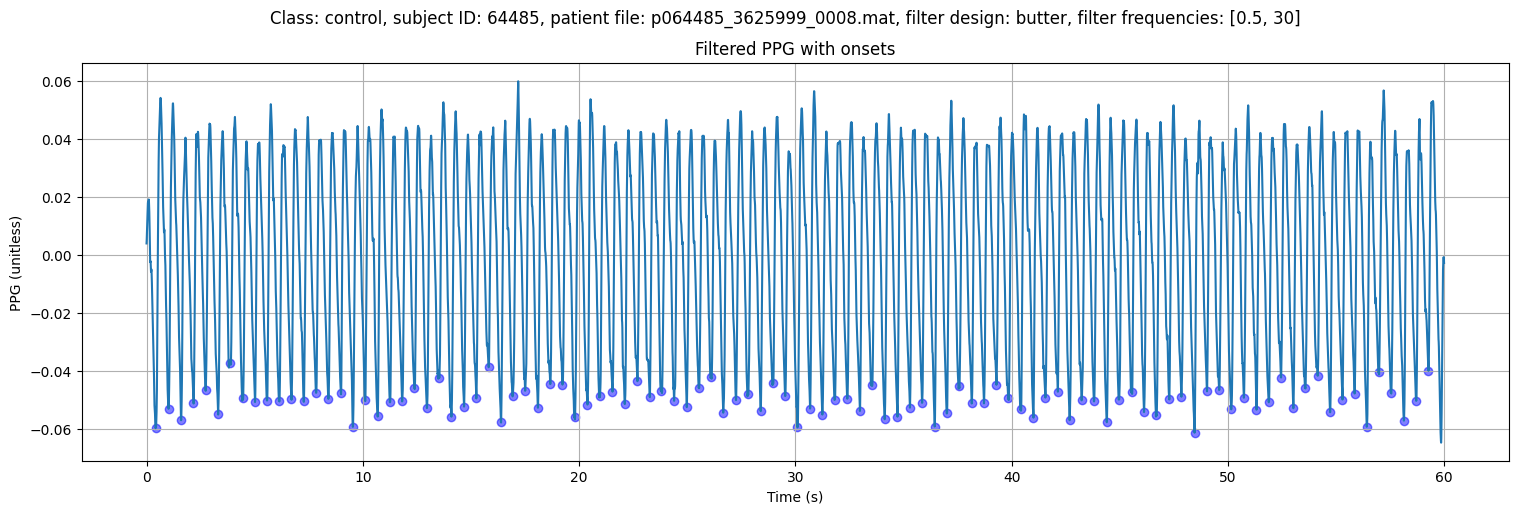

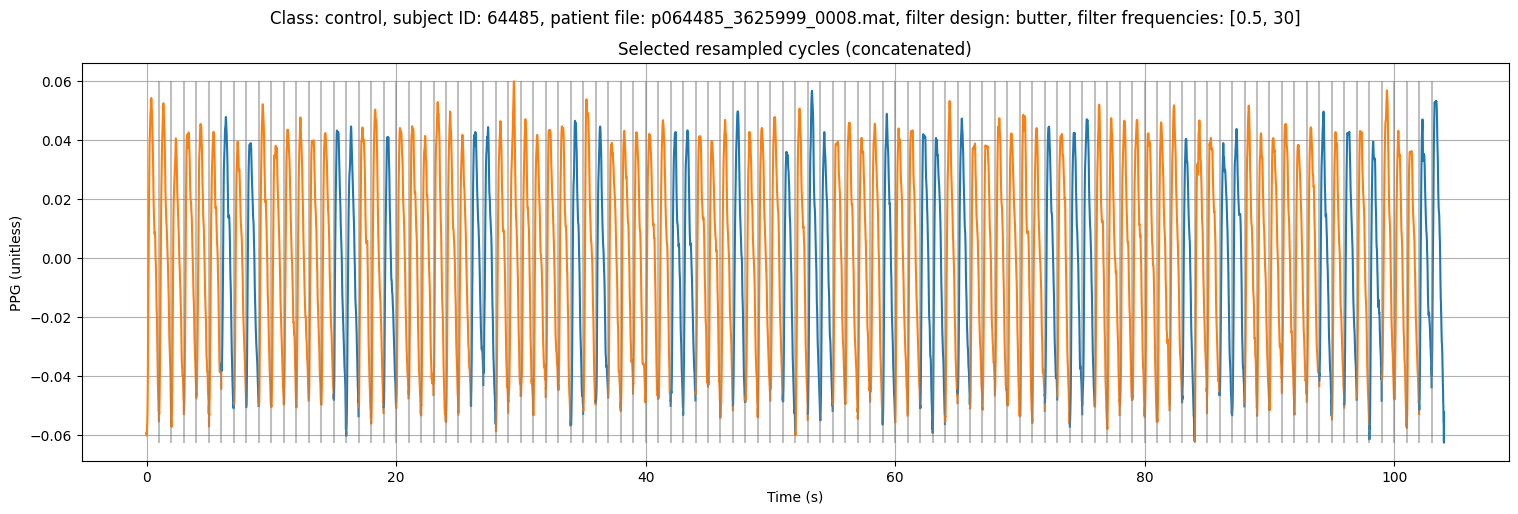

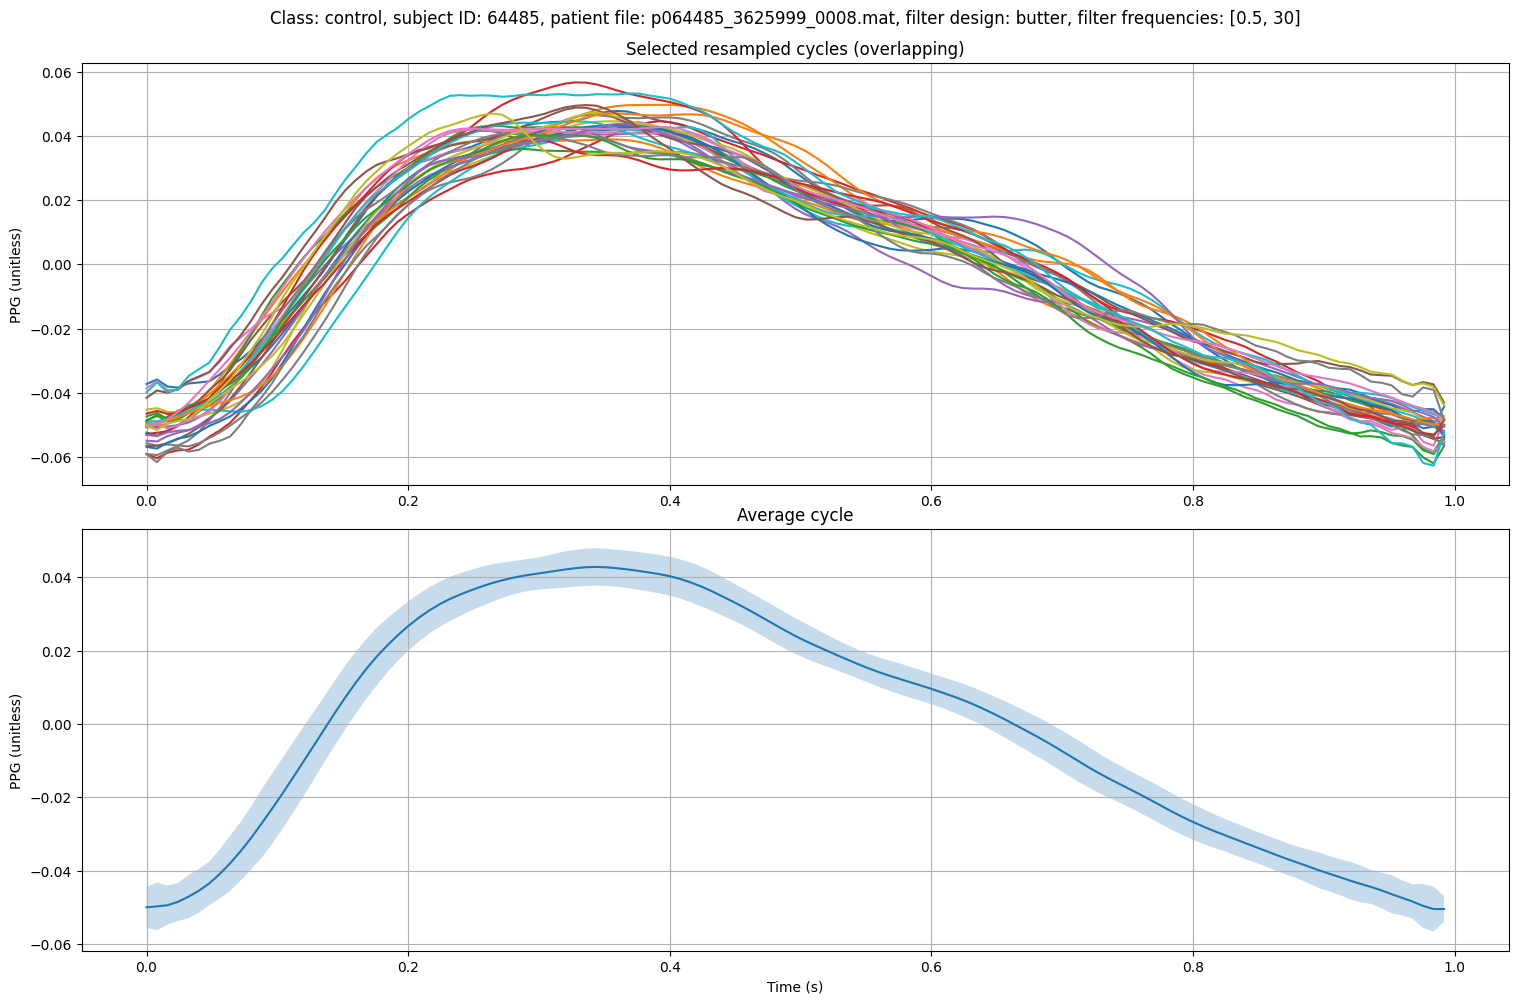

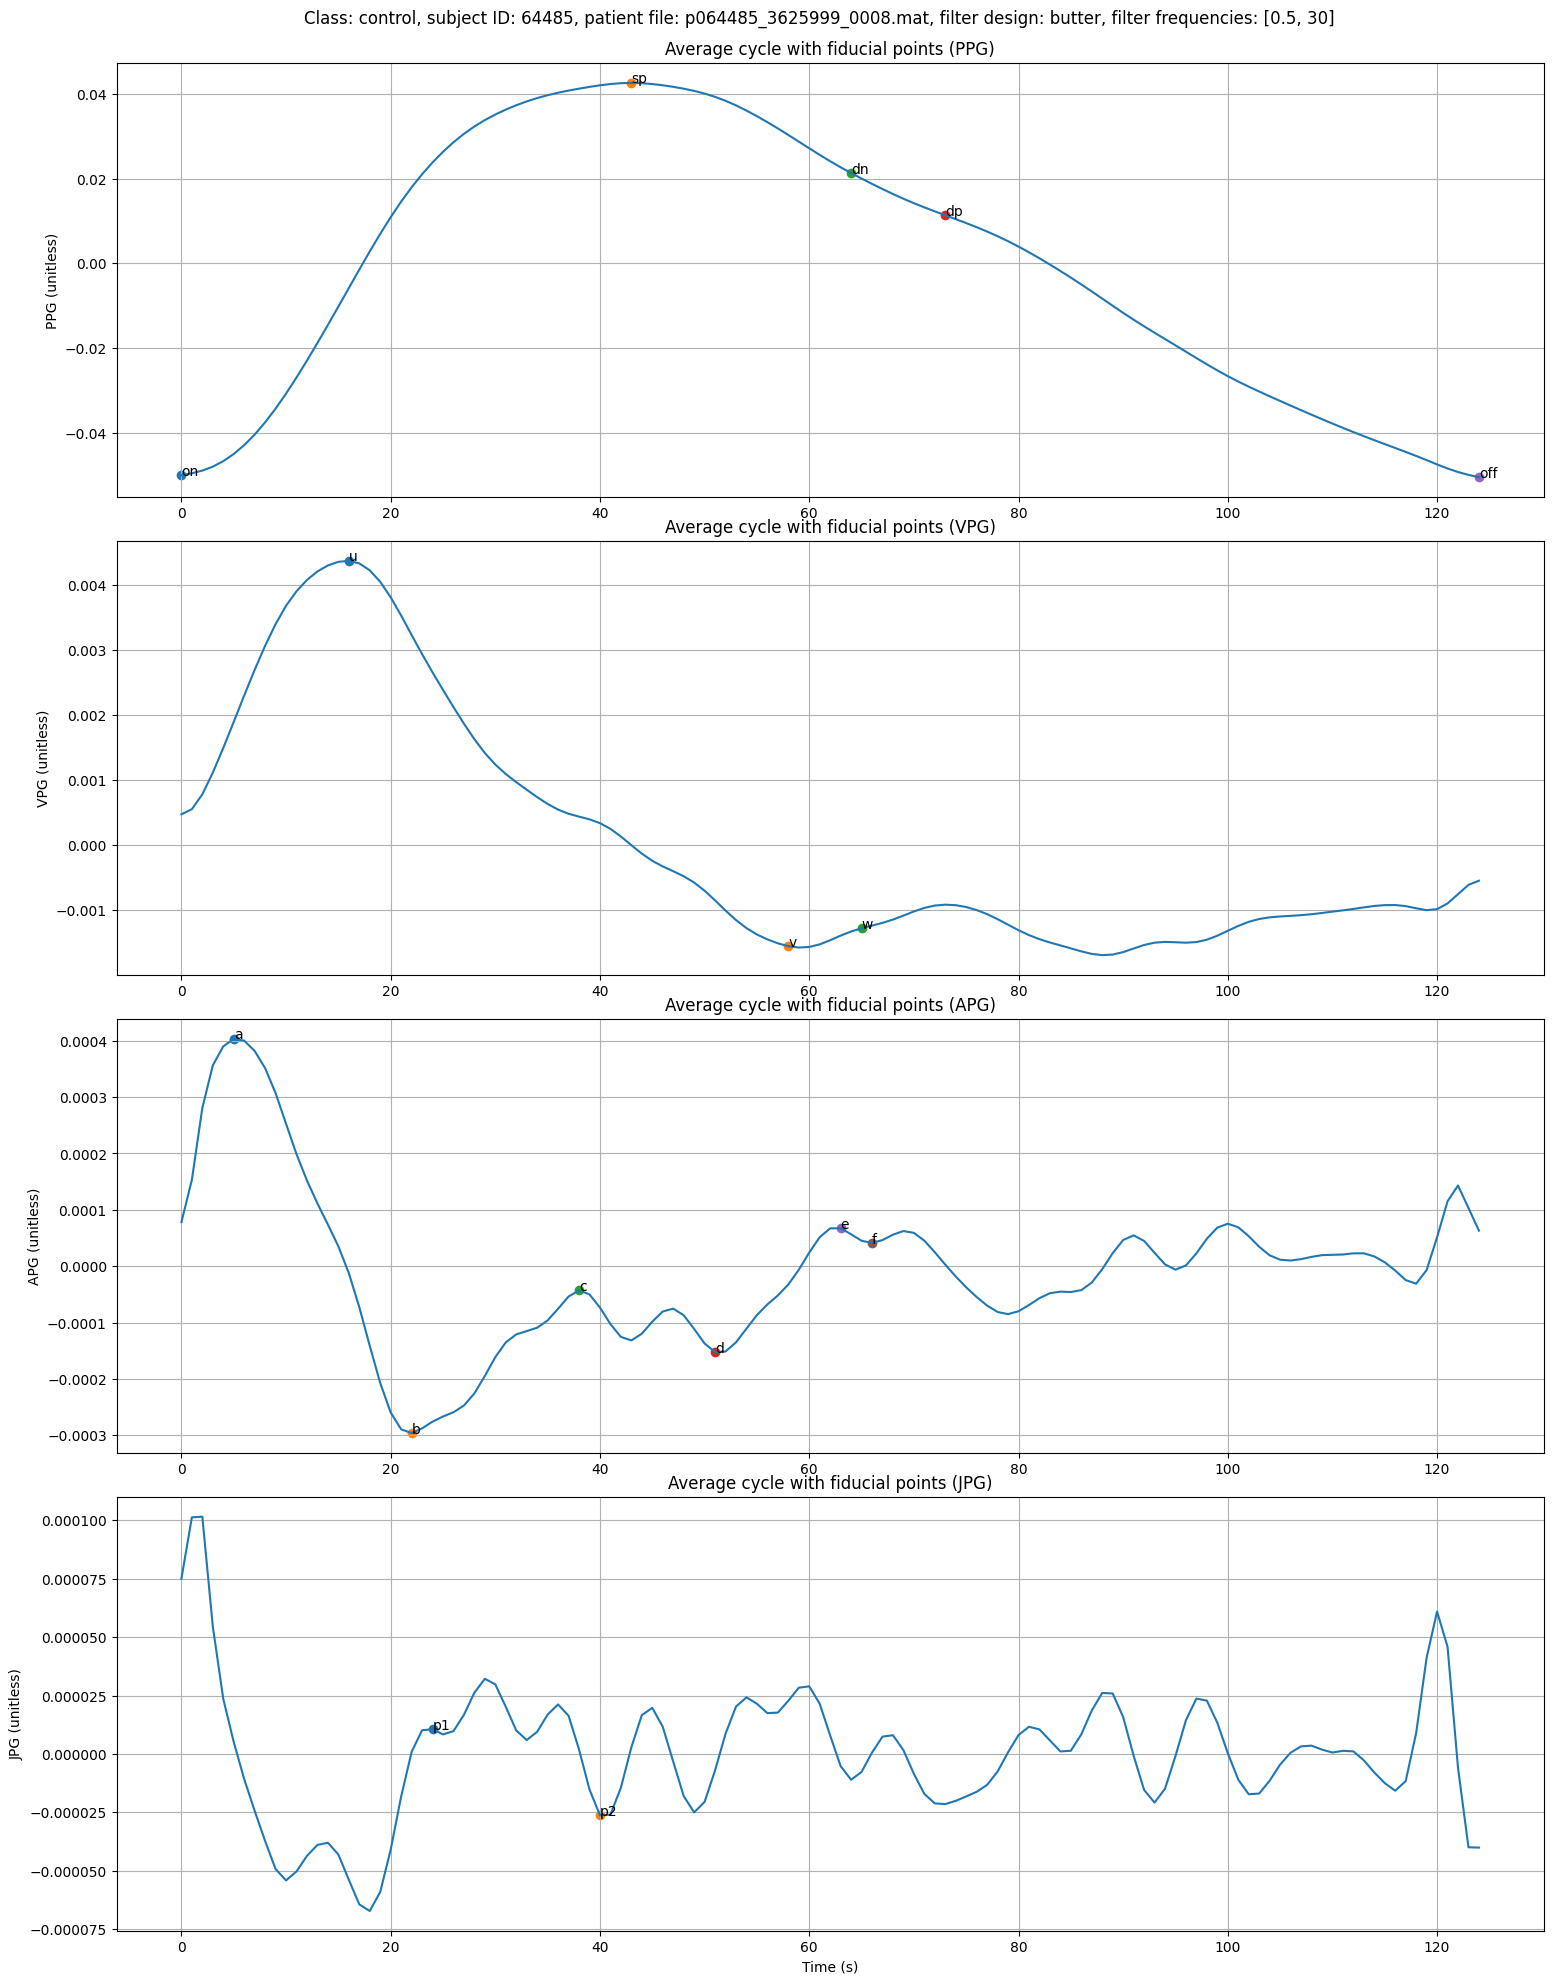

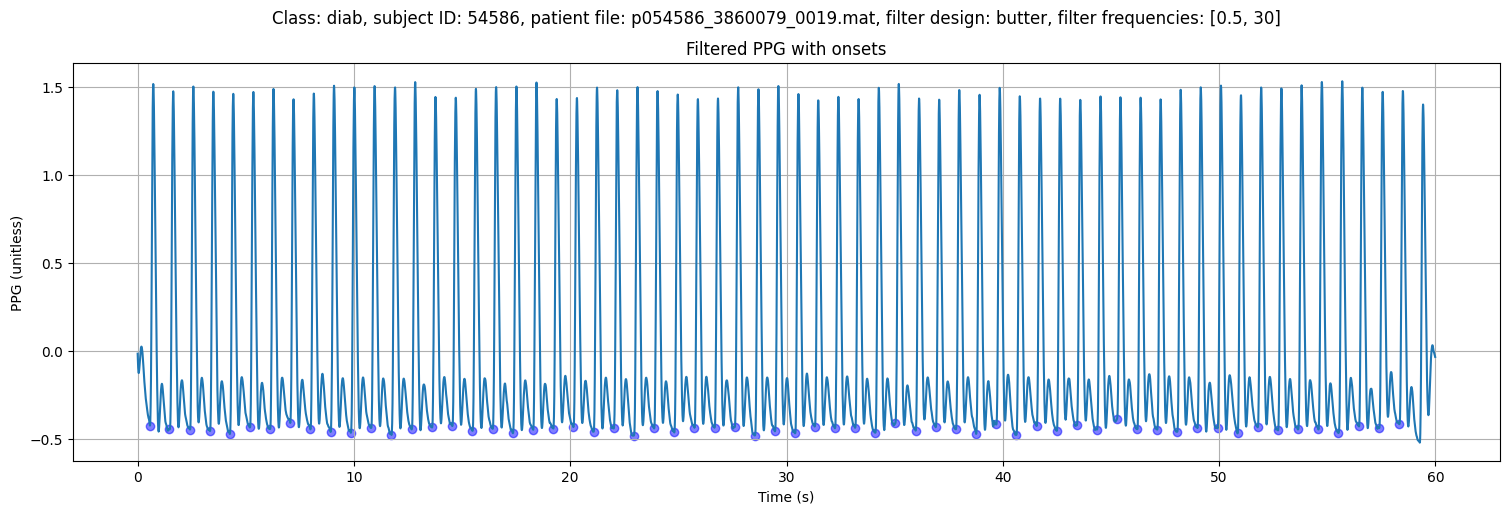

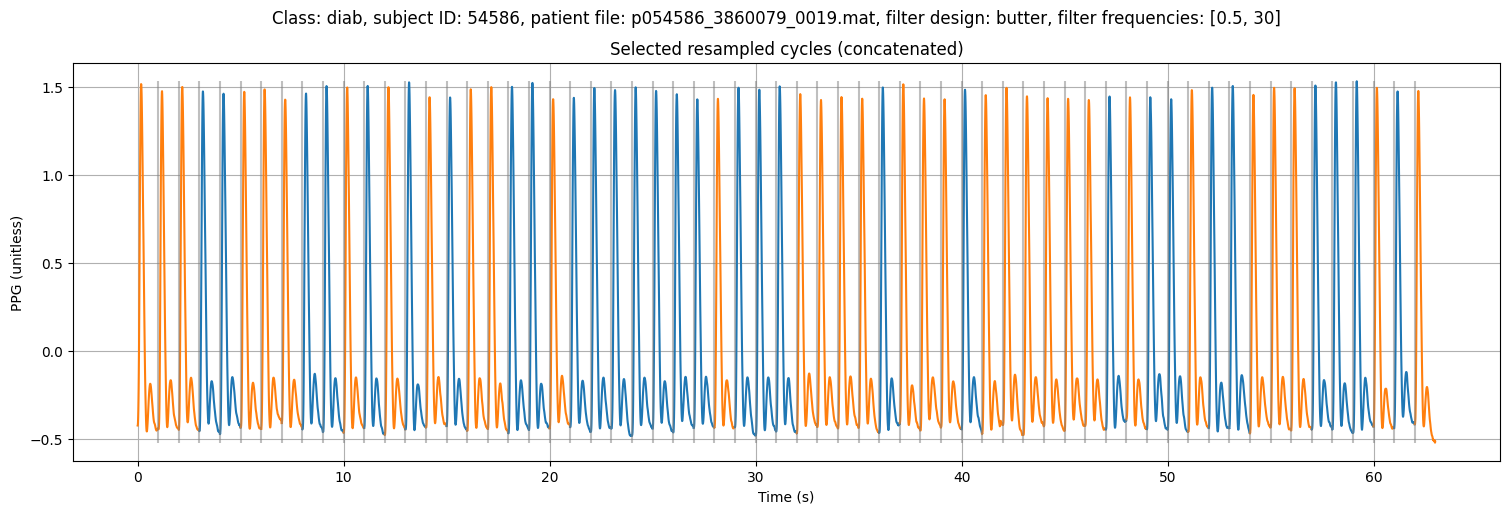

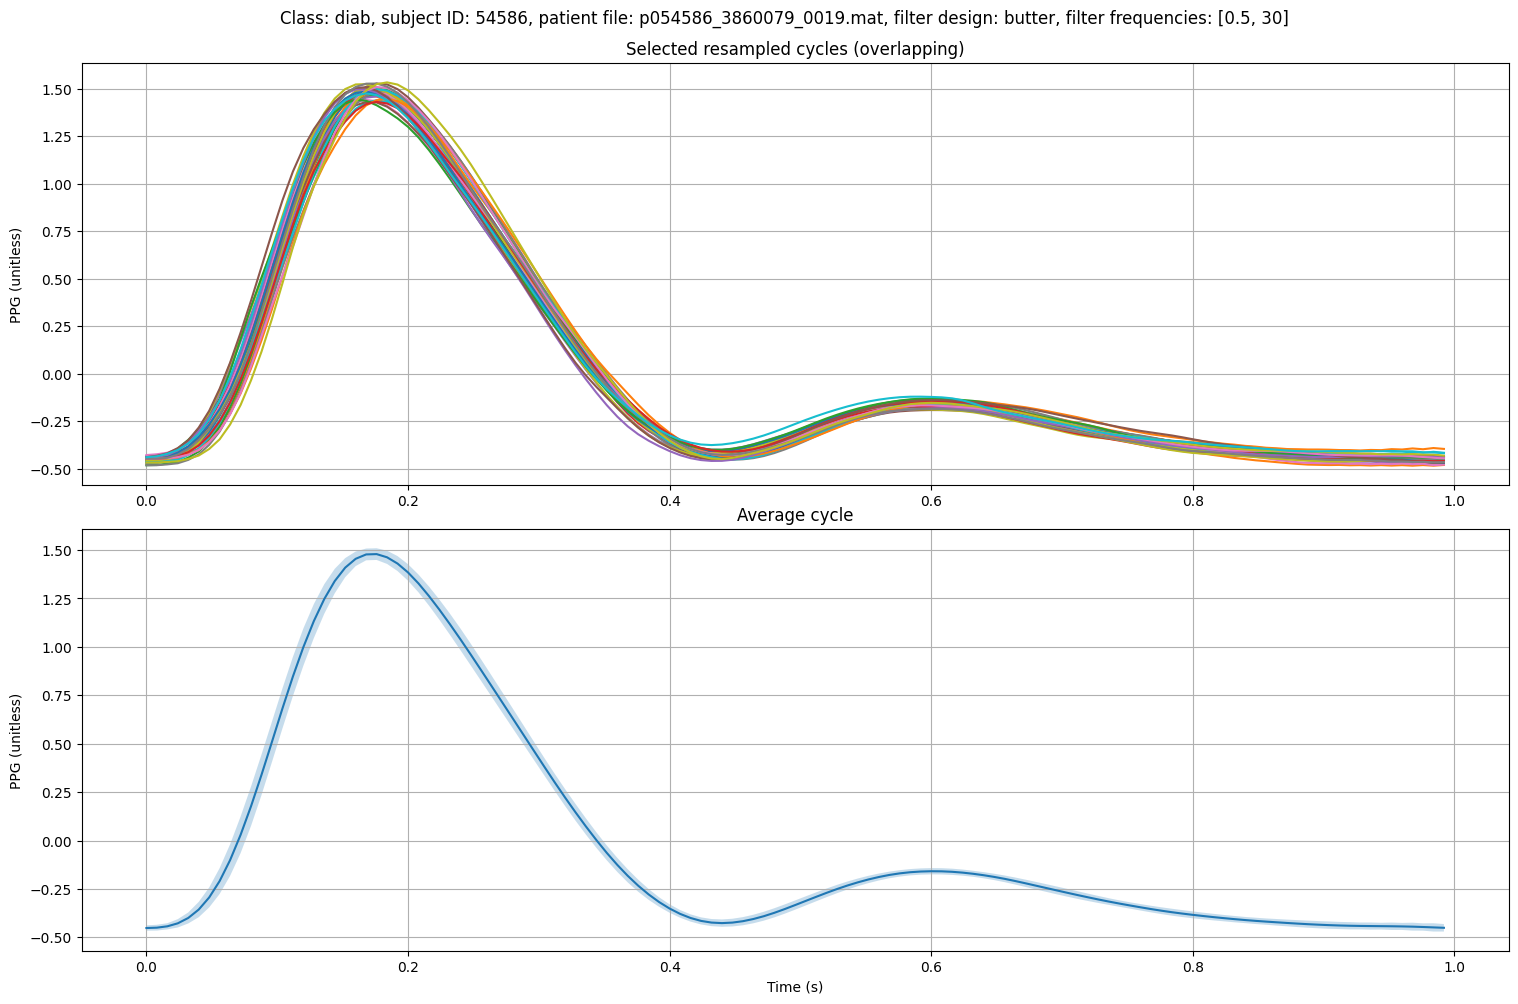

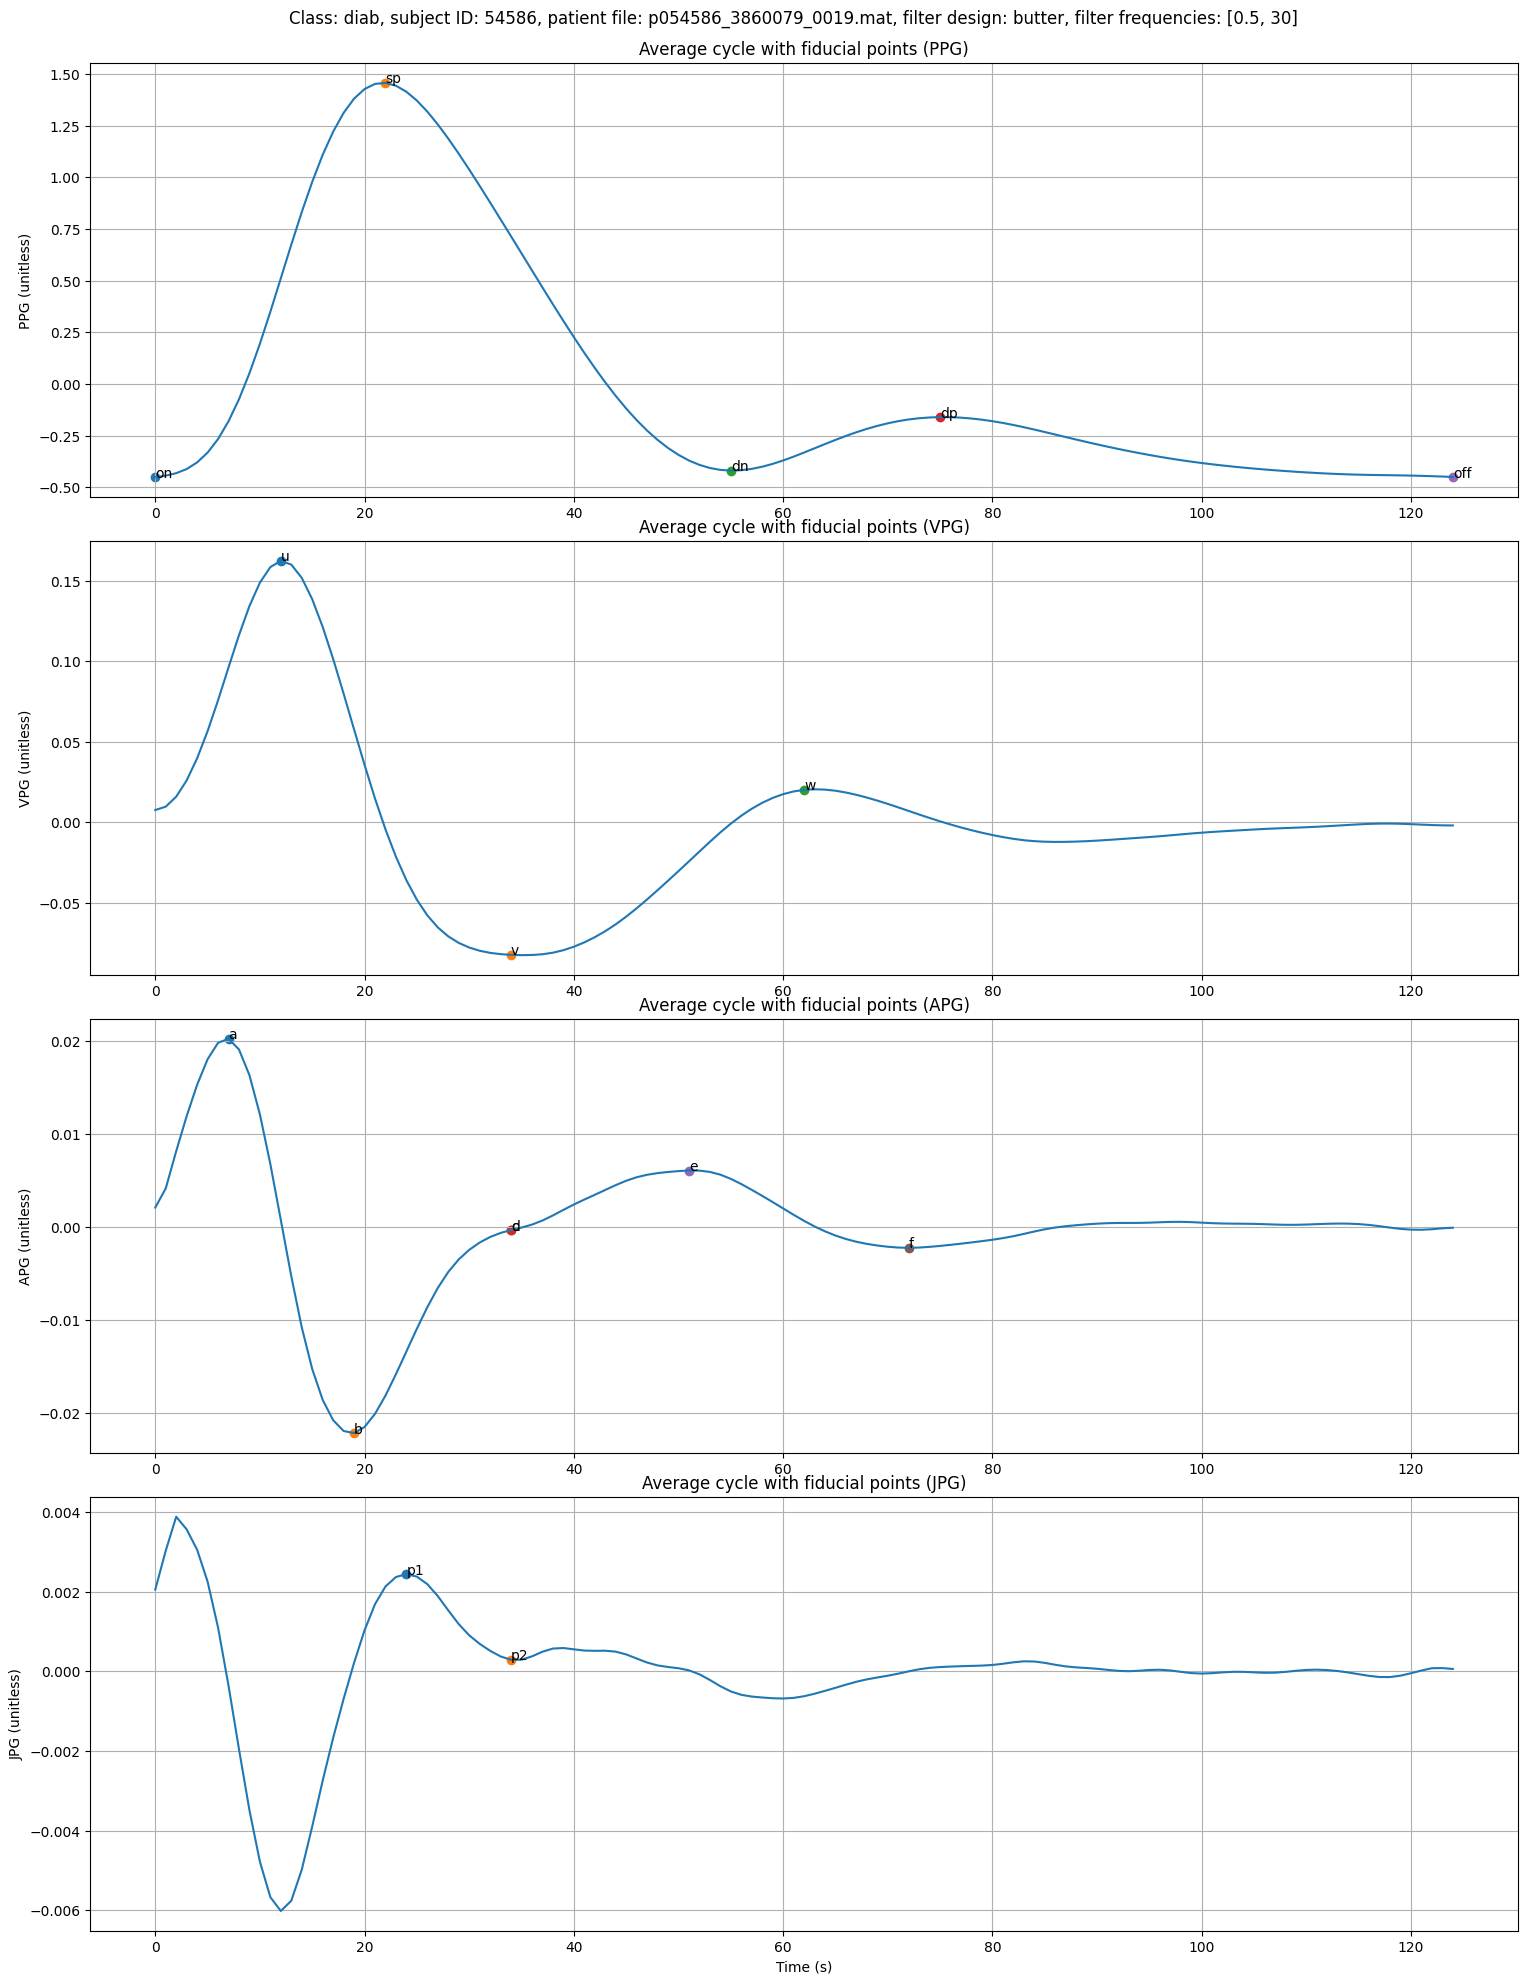

In [17]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
# wns = [[0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    # if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
    if subject_id not in [64485, 54586]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    # print(len(ppg_onsets))

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig_s, axes_s = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_s: tuple[plt.Axes]
    fig_s.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_s.tight_layout(rect=[0, 0, 1, 0.98])

    fig_r, axes_r = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))
    axes_r: tuple[plt.Axes]
    fig_r.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_r.tight_layout(rect=[0, 0, 1, 0.98])

    fig_c, axes_c = plt.subplots(nrows=2, ncols=1, figsize=(15, 10))
    axes_c: tuple[plt.Axes]
    fig_c.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_c.tight_layout(rect=[0, 0, 1, 0.98])

    fig_d, axes_d = plt.subplots(nrows=4, ncols=1, figsize=(15, 20))
    axes_d: tuple[plt.Axes]
    fig_d.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig_d.tight_layout(rect=[0, 0, 1, 0.98])

    axes_s.plot(t - s0 / fs, ppg_filt)
    axes_s.scatter(t[df_cycles['on']] - s0 / fs, ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes_s.set_title('Filtered PPG with onsets')
    axes_s.set_xlabel('Time (s)')
    axes_s.set_ylabel('PPG (unitless)')
    axes_s.grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    # print(len(ppg_peaks) == len(cycles))

    cycles['peaks'] = ppg_peaks

    resampled_cycle_signals = []
    resampled_cycle_peaks = []
    for c, (on, off, peak) in enumerate(cycles.itertuples(index=False)):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        new_peak = int(round((c + (peak - on) / (off - on)) * fs))
        resampled_cycle_peaks.append(new_peak)
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_peaks = np.array(resampled_cycle_peaks)

    resampled_cycle_qualities_tm = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='templatematch')
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.mean(axis=1)

    # resampled_cycle_qualities_ho = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='ho2025')
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.reshape(resampled_cycle_signals.shape)
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.mean(axis=1)

    resampled_cycle_qualities_ds = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='dissimilarity')
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.mean(axis=1)

    # TODO: apply multiple quality filters and sorts

    # TODO: remove first and last cycles

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)
    # sorted_idxs = np.argsort(resampled_cycle_qualities_ds)[::-1]

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes_r.plot(time, signal, color='C0' if selected else 'C1')
    axes_r.vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes_r.set_title('Selected resampled cycles (concatenated)')
    axes_r.set_xlabel('Time (s)')
    axes_r.set_ylabel('PPG (unitless)')
    axes_r.grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes_c[0].plot(cycle_signal_time, signal)
    axes_c[0].set_title('Selected resampled cycles (overlapping)')
    axes_c[0].set_ylabel('PPG (unitless)')
    axes_c[0].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes_c[1].plot(cycle_signal_time, cycle_signal_mean)
    axes_c[1].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes_c[1].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes_c[1].set_title('Average cycle')
    axes_c[1].set_xlabel('Time (s)')
    axes_c[1].set_ylabel('PPG (unitless)')
    axes_c[1].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            peaks=peaks,
            onsets=onsets,
            smoothing=True,
            sm_wins={'ppg': 30},
            # savgol=True,
            # sg_win=15,
            # sg_poly=3,
            check_ppg_len=False,
        )

    t_pts = fp.get_fp()

    for c in t_pts.index:
        # for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
        #     t_pts[m][c] += 0
        # for n, m in enumerate(['u', 'v', 'w']):
        #     t_pts[m][c] += 0
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            t_pts.loc[c, m] += 1
        for n, m in enumerate(['p1', 'p2']):
            t_pts.loc[c, m] += 1

    # axes_d[0].plot(cycle_signal_mean)
    axes_d[0].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes_d[0].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes_d[0].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes_d[0].set_title('Average cycle with fiducial points (PPG)')
    # axes_d[0].set_xlabel('Time (s)')
    axes_d[0].set_ylabel('PPG (unitless)')
    axes_d[0].grid()

    axes_d[1].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes_d[1].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes_d[1].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes_d[1].set_title('Average cycle with fiducial points (VPG)')
    # axes_d[1].set_xlabel('Time (s)')
    axes_d[1].set_ylabel('VPG (unitless)')
    axes_d[1].grid()

    axes_d[2].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes_d[2].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes_d[2].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes_d[2].set_title('Average cycle with fiducial points (APG)')
    # axes_d[2].set_xlabel('Time (s)')
    axes_d[2].set_ylabel('APG (unitless)')
    axes_d[2].grid()

    axes_d[3].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes_d[3].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes_d[3].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes_d[3].set_title('Average cycle with fiducial points (JPG)')
    axes_d[3].set_xlabel('Time (s)')
    axes_d[3].set_ylabel('JPG (unitless)')
    axes_d[3].grid()

    # fig_s.savefig(f'images/doc/{subject_id}_signal.png')
    # fig_r.savefig(f'images/doc/{subject_id}_resampled.png')
    # fig_c.savefig(f'images/doc/{subject_id}_cycle.png')
    fig_d.savefig(f'images/doc/{subject_id}_points.pdf')

In [ ]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
# wns = [[0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    # if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
    if subject_id not in [67763, 76237]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_peaks = ppg_peaks[(ppg_peaks > ppg_onsets[0]) & (ppg_peaks < ppg_onsets[-1])]

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(15, 40))
    axes: tuple[plt.Axes]
    fig.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    axes[0].plot(t, ppg_filt)
    axes[0].scatter(t[df_cycles['on']], ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes[0].set_title('Filtered PPG with onsets')
    axes[0].grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    # print(len(ppg_peaks) == len(cycles))

    cycles['peaks'] = ppg_peaks

    resampled_cycle_signals = []
    resampled_cycle_peaks = []
    for c, (on, off, peak) in enumerate(cycles.itertuples(index=False)):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        new_peak = int(round((c + (peak - on) / (off - on)) * fs))
        resampled_cycle_peaks.append(new_peak)
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_peaks = np.array(resampled_cycle_peaks)

    resampled_cycle_qualities_tm = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='templatematch')
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_tm = resampled_cycle_qualities_tm.mean(axis=1)

    # resampled_cycle_qualities_ho = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='ho2025')
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.reshape(resampled_cycle_signals.shape)
    # resampled_cycle_qualities_ho = resampled_cycle_qualities_ho.mean(axis=1)

    resampled_cycle_qualities_ds = nk.ppg.ppg_quality(resampled_cycle_signals.flatten(), peaks=resampled_cycle_peaks, sampling_rate=fs, method='dissimilarity')
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.reshape(resampled_cycle_signals.shape)
    resampled_cycle_qualities_ds = resampled_cycle_qualities_ds.mean(axis=1)

    # TODO: apply multiple quality filters and sorts

    # TODO: remove first and last cycles

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)
    # sorted_idxs = np.argsort(resampled_cycle_qualities_ds)[::-1]

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes[1].plot(time, signal, color='C0' if selected else 'C1')
    axes[1].vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes[1].set_title('Selected resampled cycles (concatenated)')
    axes[1].grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes[2].plot(cycle_signal_time, signal)
    axes[2].set_title('Selected resampled cycles (overlapping)')
    axes[2].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes[3].plot(cycle_signal_time, cycle_signal_mean)
    axes[3].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes[3].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes[3].set_title('Average cycle')
    axes[3].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            peaks=peaks,
            onsets=onsets,
            smoothing=True,
            sm_wins={'ppg': 30},
            # savgol=True,
            # sg_win=15,
            # sg_poly=3,
            check_ppg_len=False,
        )

    t_pts = fp.get_fp()

    for c in t_pts.index:
        # for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
        #     t_pts[m][c] += 0
        # for n, m in enumerate(['u', 'v', 'w']):
        #     t_pts[m][c] += 0
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            t_pts.loc[c, m] += 1
        for n, m in enumerate(['p1', 'p2']):
            t_pts.loc[c, m] += 1

    # axes[4].plot(cycle_signal_mean)
    axes[4].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes[4].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes[4].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes[4].set_title('Average cycle with fiducial points (PPG)')
    axes[4].grid()

    axes[5].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes[5].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes[5].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes[5].set_title('Average cycle with fiducial points (VPG)')
    axes[5].grid()

    axes[6].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes[6].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes[6].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes[6].set_title('Average cycle with fiducial points (APG)')
    axes[6].grid()

    axes[7].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes[7].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes[7].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes[7].set_title('Average cycle with fiducial points (JPG)')
    axes[7].grid()

In [ ]:
# designs = ['cheby2', 'butter', 'bessel']
designs = ['butter']

# wns = [10, 15, 20, 25, 30, 35, [0.5, 10], [0.5, 12], [0.5, 15], [0.5, 20], [0.5, 25], [0.5, 30], [0.5, 35], [0.1, 30]]
# wns = [[0.1, 30], [0.5, 12]]
# wns = [[0.5, 12]]
wns = [[0.5, 30]]

# subject_records = list(df_subjects.loc[:1, ['subject_id', 'class', 'patient_file']].itertuples(index=False))
# subject_records = list(df_subjects.sample(1, random_state=0)[['subject_id', 'class', 'patient_file']].itertuples(index=False))
subject_records = df_subjects[['subject_id', 'class', 'patient_file']].itertuples(index=False)

for (subject_id, category, patient_file), design, wn in tqdm(list(itertools.product(subject_records, designs, wns))):

    #
    # select, load and filter signal
    #

    if subject_id not in [67763, 54586, 47874, 93566, 64485, 76237]:
        continue

    mat = scipy.io.loadmat(patient_file)

    t = mat['time'].squeeze()
    ppg_raw = mat['data'].squeeze()

    s0 = 2 * 60 * fs
    s1 = s0 + 1 * 60 * fs
    t = t[s0:s1]
    ppg_raw = ppg_raw[s0:s1]

    filt = make_filter(design, wn)
    ppg_filt = scipy.signal.sosfiltfilt(filt, ppg_raw)

    #
    # load annotated peaks and onsets
    #

    points_path = csv_dir / 'points.csv'

    df_records = pd.read_csv(
        points_path,
        dtype={
            'subject_id': pd.Int64Dtype(),
            'signal_name': pd.StringDtype(),
            'x': pd.Float64Dtype(),
            'y': pd.Float64Dtype(),
            'label': pd.Int64Dtype(),
        }
    )

    df_records = df_records.sort_values(['subject_id', 'signal_name', 'label', 'x'])

    df_records = df_records.set_index(['subject_id', 'signal_name', 'label'])

    ppg_peaks = (df_records.loc[(subject_id, 'PLETH', 1), 'x'] * 125).round().astype(int).to_numpy()

    ppg_onsets = (df_records.loc[(subject_id, 'PLETH', 3), 'x'] * 125).round().astype(int).to_numpy()

    #
    # get peaks and cycles from filtered signal
    #

    df_cycles = pd.DataFrame(itertools.pairwise(ppg_onsets), columns=['on', 'off'])

    fig, axes = plt.subplots(nrows=8, ncols=1, figsize=(15, 40))
    axes: tuple[plt.Axes]
    fig.suptitle(f'Class: {category}, subject ID: {subject_id}, patient file: {patient_file.stem}.mat, filter design: {design}, filter frequencies: {wn}')
    fig.tight_layout(rect=[0, 0, 1, 0.98])

    axes[0].plot(t, ppg_filt)
    axes[0].scatter(t[df_cycles['on']], ppg_filt[df_cycles['on']], color='blue', alpha=0.5)
    axes[0].set_title('Filtered PPG with onsets')
    axes[0].grid()

    #
    # get signal quality, normalize cycle length, filter cycles, get average cycle signal and rebuild signal
    #

    ppg_quality_tm = nk.ppg.ppg_quality(ppg_filt, peaks=ppg_peaks, sampling_rate=fs, method='templatematch')
    ppg_quality_ho = nk.ppg.ppg_quality(ppg_filt, peaks=ppg_peaks, sampling_rate=fs, method='ho2025')

    # selected_cycles = df_cycles.sample(min_num_cycles, random_state=0)
    cycles = df_cycles

    resampled_cycle_signals = []
    resampled_cycle_qualities_tm = []
    resampled_cycle_qualities_ho = []
    # resampled_cycles = []
    for on, off in cycles.itertuples(index=False):
        resampled_cycle_signal = scipy.signal.resample(ppg_filt[on:off], fs)
        resampled_cycle_signals.append(resampled_cycle_signal)
        resampled_cycle_quality_tm = np.mean(scipy.signal.resample(ppg_quality_tm[on:off], fs))
        resampled_cycle_qualities_tm.append(resampled_cycle_quality_tm)
        resampled_cycle_quality_ho = np.mean(scipy.signal.resample(ppg_quality_ho[on:off], fs))
        resampled_cycle_qualities_ho.append(resampled_cycle_quality_ho)
        # resampled_cycles.append((resampled_cycle_signal, resampled_cycle_quality_tm, resampled_cycle_quality_ho))
    resampled_cycle_signals = np.array(resampled_cycle_signals)
    resampled_cycle_qualities_tm = np.array(resampled_cycle_qualities_tm)
    resampled_cycle_qualities_ho = np.array(resampled_cycle_qualities_ho)
    # resampled_cycles = np.array(resampled_cycles)

    # TODO: remove cycles where points are not being detected

    # TODO: apply multiple quality filters and sorts

    sorted_idxs = np.argsort(resampled_cycle_qualities_tm)

    selected_cond = sorted_idxs < target_num_cycles

    selected_cycle_signals = resampled_cycle_signals[selected_cond]

    num_cycles = resampled_cycle_signals.shape[0]

    for c, (signal, selected) in enumerate(zip(resampled_cycle_signals, selected_cond)):
        time = np.linspace(c, (c + 1) - 1 / fs, fs)
        axes[1].plot(time, signal, color='C0' if selected else 'C1')
    axes[1].vlines(np.arange(1, num_cycles, 1), np.min(resampled_cycle_signals), np.max(resampled_cycle_signals), color='grey', alpha=0.5)
    axes[1].set_title('Selected resampled cycles (concatenated)')
    axes[1].grid()

    cycle_signal_time = np.linspace(0, 1 - 1 / fs, fs)

    for signal in selected_cycle_signals:
        axes[2].plot(cycle_signal_time, signal)
    axes[2].set_title('Selected resampled cycles (overlapping)')
    axes[2].grid()

    cycle_signal_mean = np.mean(selected_cycle_signals, axis=0)
    cycle_signal_std = np.std(selected_cycle_signals, axis=0)

    axes[3].plot(cycle_signal_time, cycle_signal_mean)
    axes[3].fill_between(cycle_signal_time, cycle_signal_mean - cycle_signal_std, cycle_signal_mean + cycle_signal_std, alpha=0.25)
    # axes[3].errorbar(cycle_signal_time, cycle_signal_mean, cycle_signal_std)
    axes[3].set_title('Average cycle')
    axes[3].grid()

    #
    # get fiducial points from mean cycle
    #

    signal_file = f'{patient_file.stem}_{design}_{wn}.mat'

    nc = 1
    # cycle_signal_mean_repeated = np.tile(cycle_signal_mean[:-1], nc)
    cycle_signal_mean_repeated = np.tile(cycle_signal_mean, nc)
    scipy.io.savemat((pyppg_dir / '2+1_mean' / signal_file).as_posix(), {'Fs': fs, 'Data': cycle_signal_mean_repeated})

    cycle_signal_peak = np.argmax(cycle_signal_mean)
    peaks = np.arange(cycle_signal_peak, cycle_signal_peak + (nc + 1) * 125, 125)
    # onsets = np.append(np.arange(0, nc * 125, 125), nc * 125 - 1)
    onsets = np.arange(0, (nc + 1) * 125, 125)
    onsets[-1] -= 1

    # with contextlib.redirect_stdout(None), contextlib.redirect_stderr(None):
    with contextlib.redirect_stderr(None):
        s, fp = ppg_example(
            data_path=(pyppg_dir / '2+1_mean' / signal_file).as_posix(),
            peaks=peaks,
            onsets=onsets,
            # smoothing=True,
            # sm_wins={'ppg': 24},
            savgol=True,
            sg_win=5,
            sg_poly=3,
            check_ppg_len=False,
        )

    t_pts = fp.get_fp()

    for c in t_pts.index:
        # for n, m in enumerate(['u', 'v', 'w']):
        #     t_pts[m][c] += 0
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            t_pts[m][c] += 1
        for n, m in enumerate(['p1', 'p2']):
            t_pts[m][c] += 1

    # axes[4].plot(cycle_signal_mean)
    axes[4].plot(s.ppg)
    for c in t_pts.index:
        for n, m in enumerate(['on', 'sp', 'dn', 'dp', 'off']):
            if not pd.isna(t_pts[m][c]):
                axes[4].scatter(t_pts[m][c], s.ppg[t_pts[m][c]], color=f'C{n}')
                axes[4].annotate(m, (t_pts[m][c], s.ppg[t_pts[m][c]]))
    axes[4].set_title('Average cycle with fiducial points (PPG)')
    axes[4].grid()

    axes[5].plot(s.vpg)
    for c in t_pts.index:
        for n, m in enumerate(['u', 'v', 'w']):
            if not pd.isna(t_pts[m][c]):
                axes[5].scatter(t_pts[m][c], s.vpg[t_pts[m][c]], color=f'C{n}')
                axes[5].annotate(m, (t_pts[m][c], s.vpg[t_pts[m][c]]))
    axes[5].set_title('Average cycle with fiducial points (VPG)')
    axes[5].grid()

    axes[6].plot(s.apg)
    for c in t_pts.index:
        for n, m in enumerate(['a', 'b', 'c', 'd', 'e', 'f']):
            if not pd.isna(t_pts[m][c]):
                axes[6].scatter(t_pts[m][c], s.apg[t_pts[m][c]], color=f'C{n}')
                axes[6].annotate(m, (t_pts[m][c], s.apg[t_pts[m][c]]))
    axes[6].set_title('Average cycle with fiducial points (APG)')
    axes[6].grid()

    axes[7].plot(s.jpg)
    for c in t_pts.index:
        for n, m in enumerate(['p1', 'p2']):
            if not pd.isna(t_pts[m][c]):
                axes[7].scatter(t_pts[m][c], s.jpg[t_pts[m][c]], color=f'C{n}')
                axes[7].annotate(m, (t_pts[m][c], s.jpg[t_pts[m][c]]))
    axes[7].set_title('Average cycle with fiducial points (JPG)')
    axes[7].grid()

    break